In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fairlearn

from fairlearn.postprocessing import ThresholdOptimizer

from IPython.display import display
from folktables import ACSDataSource, ACSIncome
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss,
    brier_score_loss, confusion_matrix, precision_score, recall_score,
)
from fairlearn.metrics import (
    MetricFrame, selection_rate, count, true_positive_rate,
    false_positive_rate, demographic_parity_difference,
    demographic_parity_ratio, equalized_odds_difference,
    equalized_odds_ratio,
)

def confusion_matrix_binary(y_true, y_pred):
    return confusion_matrix(y_true, y_pred, labels=[0, 1])

def false_positive_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fp/(tn+fp) if (tn+fp)>0 else np.nan

def true_negative_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn/(tn+fp) if (tn+fp)>0 else np.nan

def negative_predictive_value_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn/(tn+fn) if (tn+fn)>0 else np.nan

RANDOM_STATE = 42
STATE = "CA"
MAX_SAMPLES = 50_000

# Training an alternative model

In week 1, we considered SEX and RACE as sensitive attributes, but we also lerned that removing a sensitive from the predictive features is not itself a fairness guarantee as it does not remove proxies. In my work on Week 2, I decided that one's sex, race, marital status or place of birth should not decide what your income is. I called them all sensitive attributes, and I trained a model without them. However, I still observed a bias for SEX, whereas it was difficult to determine a bias for the other categories. Question is whether it is better or not to remove these features. I am taking away data, because I hope the model wont have a bias on them, but I cant be sure that that information is not encoded in some other way and there could also be legit reson why some who was married or who came from abroad earned more/less. 

Let's start from the beginning. Last time, I only looked at the new dataset and checked if it kept within the ranges provided by the feature descriptions. Let's compare the distributions to the ACSIncome dataset used in week 1

In [2]:
# Load ASCIncome from week 1
source = ACSDataSource(survey_year="2018", horizon="1-Year", survey="person")
acs = source.get_data(states=[STATE], download=True)
X_acs, y_acs, race_codes = ACSIncome.df_to_pandas(acs)

X_acs = X_acs.reset_index(drop=True)
y_ref_acs = y_acs.squeeze().astype(int).reset_index(drop=True)
# race_codes = race_codes.squeeze().reset_index(drop=True)

In [3]:
X_acs.head()

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P
0,30.0,6.0,14.0,1.0,9610.0,6.0,16.0,40.0,1.0,8.0
1,21.0,4.0,16.0,5.0,1970.0,6.0,17.0,20.0,1.0,1.0
2,65.0,2.0,22.0,5.0,2040.0,6.0,17.0,8.0,1.0,1.0
3,33.0,1.0,14.0,3.0,9610.0,36.0,16.0,40.0,1.0,1.0
4,18.0,2.0,19.0,5.0,1021.0,6.0,17.0,18.0,2.0,1.0


In [4]:
# Load data from week 2
from pathlib import Path
DATA_DIR = Path("data/data")  
train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
validation = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
test_features = pd.read_csv(DATA_DIR / "week2_test_features.csv")

display(train.head())

,row_id,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,SEX_group,RACE_group,SURVEY_BATCH,income_observed
0,0,23.0,1.0,20.0,5.0,9130.0,48.0,2.0,40.0,1.0,1.0,Male,White,B04,0
1,1,57.0,1.0,21.0,1.0,3255.0,301.0,1.0,35.0,2.0,1.0,Female,White,B06,1
2,2,29.0,1.0,21.0,1.0,6800.0,6.0,0.0,48.0,1.0,1.0,Male,White,B02,1
3,3,42.0,6.0,17.0,1.0,6200.0,313.0,1.0,40.0,1.0,1.0,Male,White,B04,0
4,4,67.0,1.0,20.0,1.0,3601.0,48.0,0.0,6.0,2.0,2.0,Female,Black,B08,0


In [ ]:
def compare_distribution(dataset1, dataset2, column, name1="Dataset 1", name2="Dataset 2"): 
    """ Compare the distribution of a categorical column across two datasets. """ 

    # Calculate proportions 
    if column in ["OCCP", "POBP", "WKHP"]:
        prop1 = dataset1[column].value_counts(normalize=True).nlargest(20) * 100 
        prop2 = dataset2[column].value_counts(normalize=True).nlargest(20) * 100
    else:
        prop1 = dataset1[column].value_counts(normalize=True) * 100 
        prop2 = dataset2[column].value_counts(normalize=True) * 100

    # Combine into one DataFrame so categories are aligned 
    proportions = pd.concat( [prop1, prop2], axis=1, keys=[name1, name2] ).fillna(0) 

    # Plot 
    proportions = proportions.sort_values(column)
    proportions.plot( kind="bar", figsize=(9, 6) ) 
    plt.xlabel(column) 
    plt.ylabel("Proportion (%)") 
    plt.title(f"Distribution of {column}") 
    plt.xticks(rotation=45) 
    plt.legend(title="Dataset") 
    plt.tight_layout() 
    plt.show()



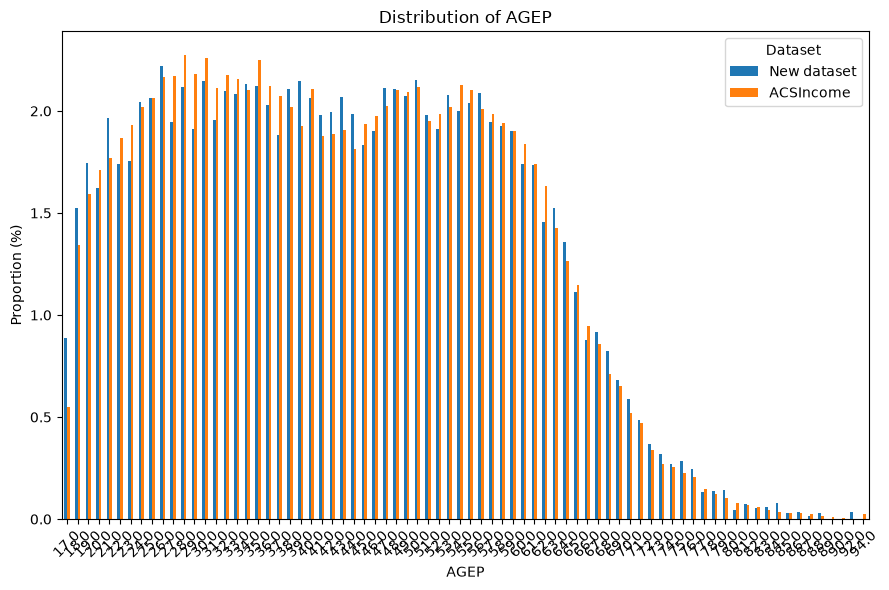

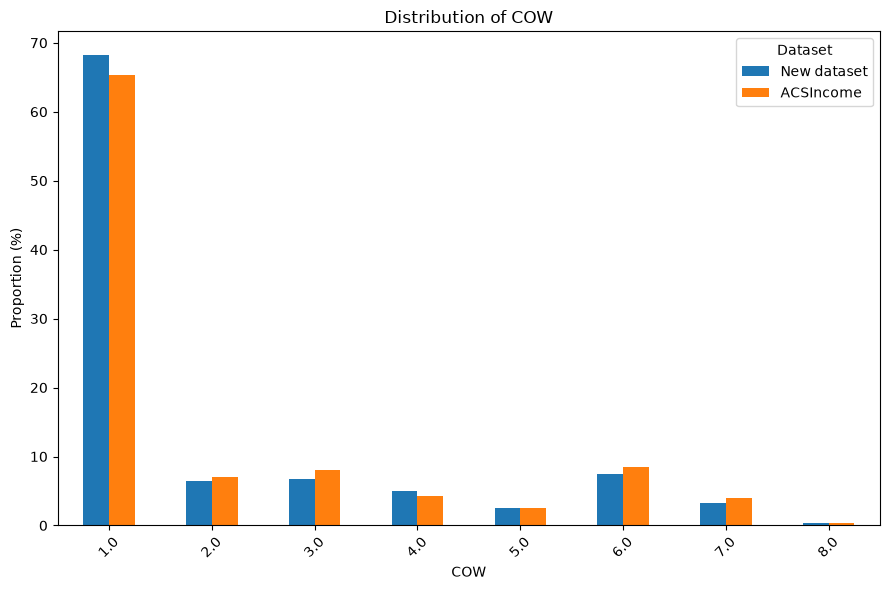

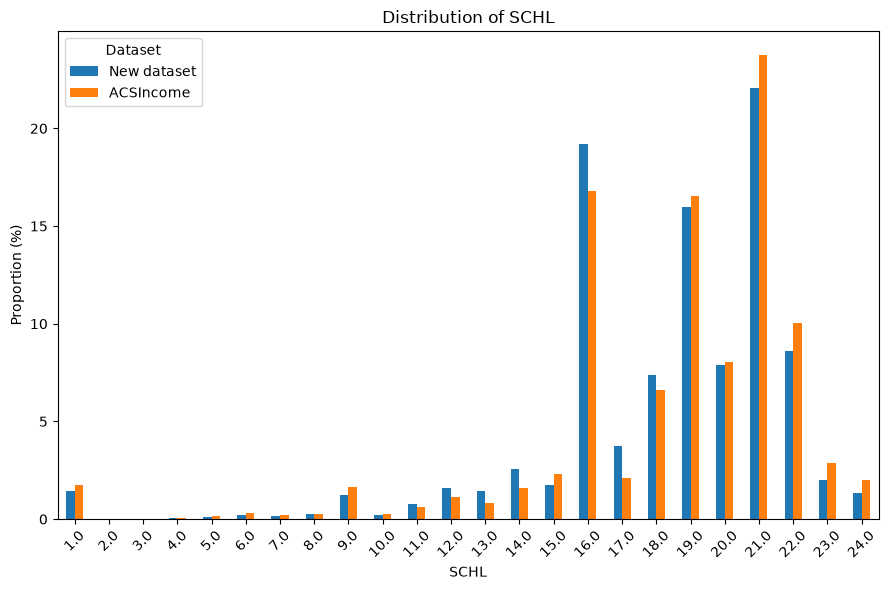

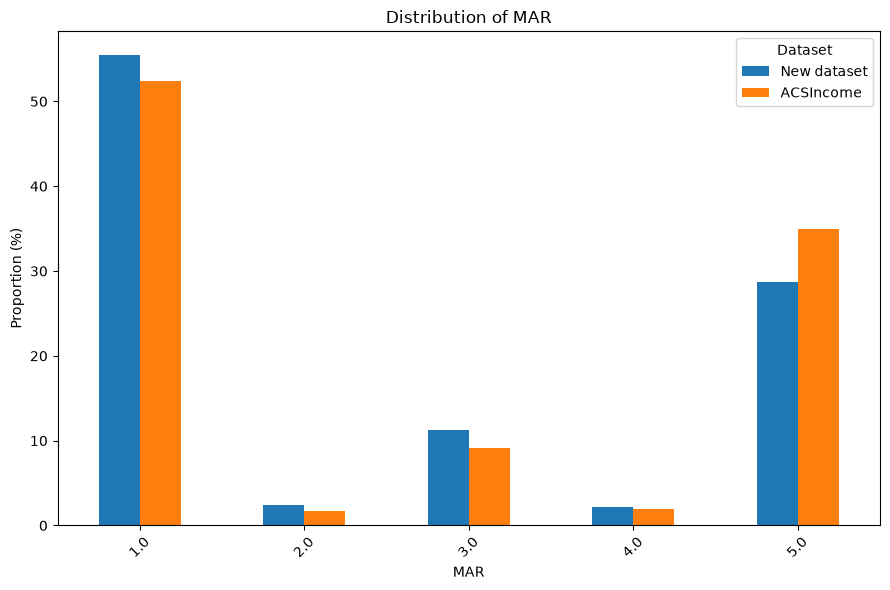

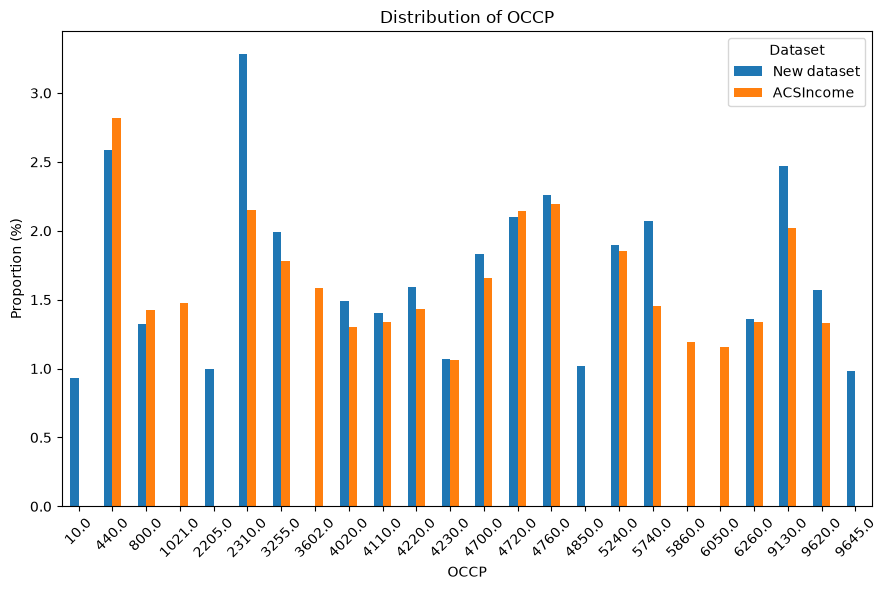

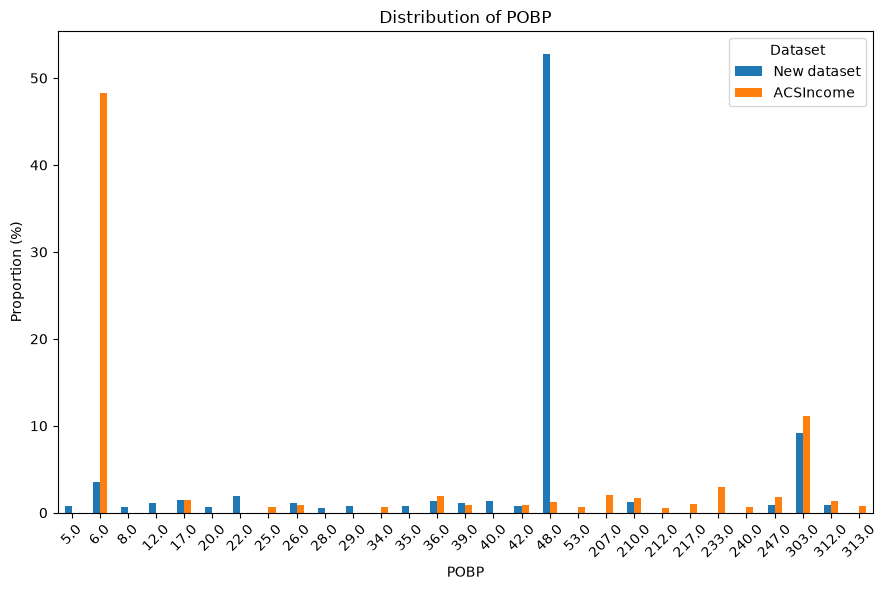

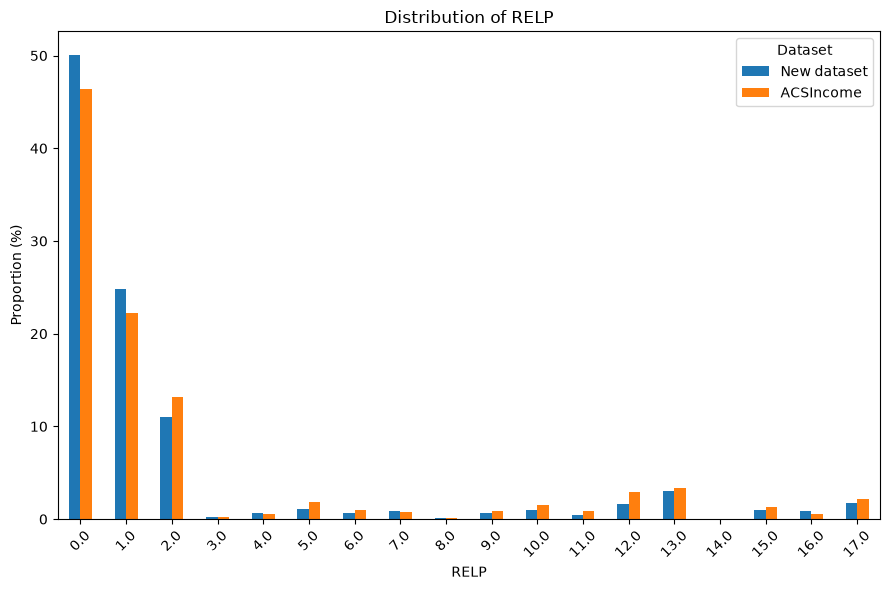

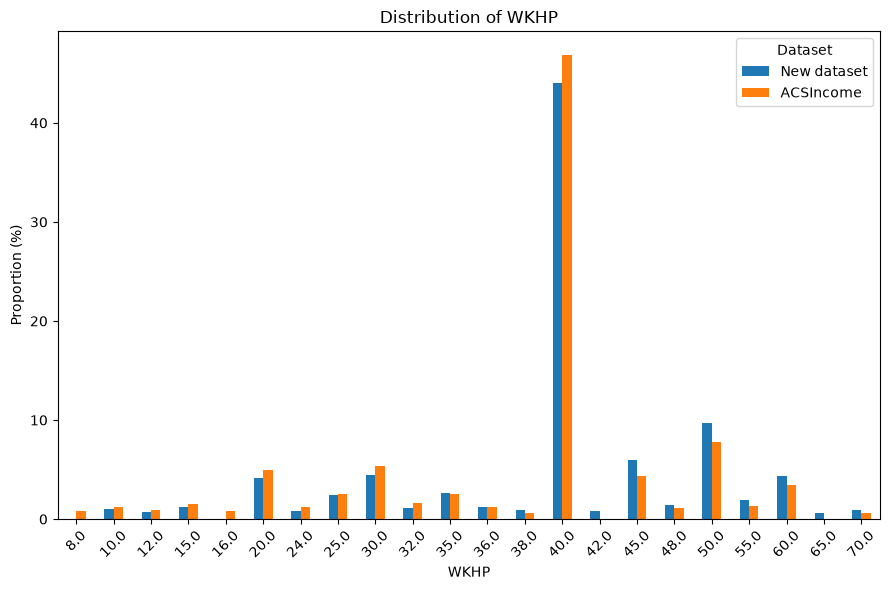

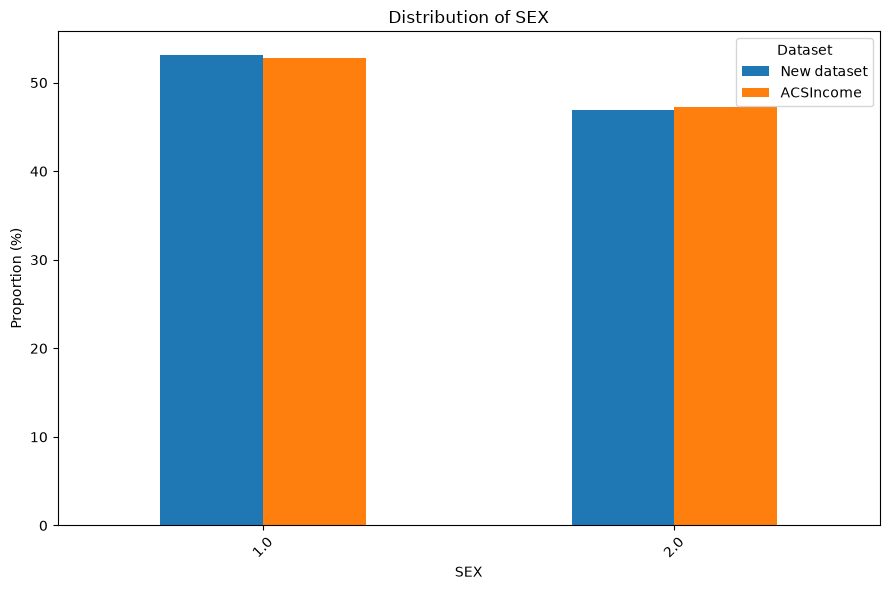

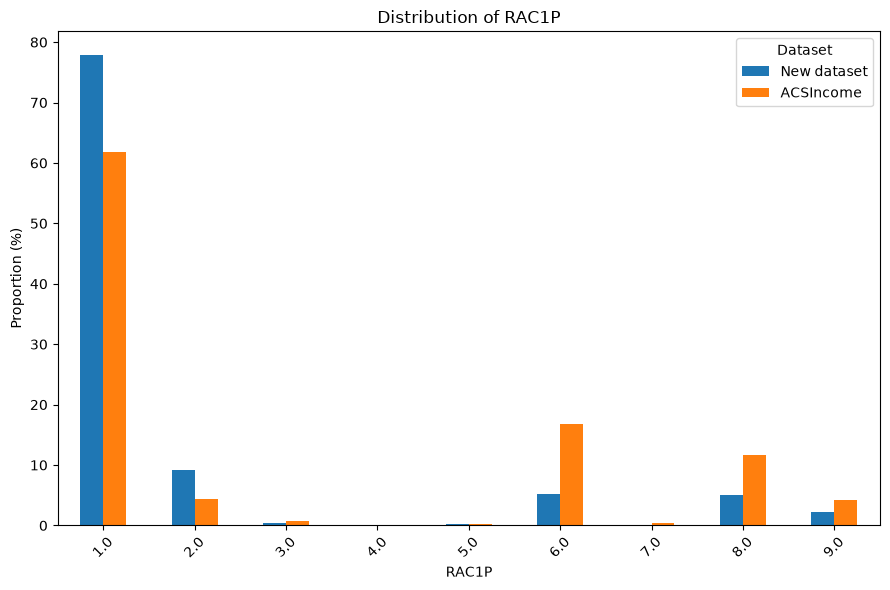

In [16]:
for col in X_acs.columns:
    compare_distribution(train, X_acs, col, name1="New dataset", name2="ACSIncome")

From the above plots, we can see some datadrift over the different columns. The biggest changes seem to be with "POBP" and "RAC1P". Before, about 48% of people in the training data came from California (US). Now, about 52% come from Texas (US). Also before, about 60% of people were white and 18% were asian. Now, 78% is white and 10% is black. Notice that for three of the columns, the plots only show the highest 20 proportions.


In [43]:
def compare_distribution_income(column, dataset):

    X = pd.merge(X_acs, y_acs, left_index=True, right_index=True)
    X_plus = X[X["PINCP"] == True]
    X_minus = X[X["PINCP"]==False]

    D_plus = dataset[dataset['income_observed'] == 1]
    D_minus = dataset[dataset['income_observed'] == 0]


    # Calculate proportions 
    if column in ["OCCP", "POBP", "WKHP"]:
        prop11 = D_plus[column].value_counts(normalize=True).nlargest(20) * 100
        prop10 = D_minus[column].value_counts(normalize=True).nlargest(20) * 100
        prop21 = X_plus[column].value_counts(normalize=True).nlargest(20) * 100
        prop20 = X_minus[column].value_counts(normalize=True).nlargest(20) * 100
    else:
        prop11 = D_plus[column].value_counts(normalize=True) * 100
        prop10 = D_minus[column].value_counts(normalize=True) * 100
        prop21 = X_plus[column].value_counts(normalize=True) * 100
        prop20 = X_minus[column].value_counts(normalize=True) * 100

    # Combine into one DataFrame so categories are aligned 
    proportions = pd.concat( [prop11, prop10, prop21, prop20], axis=1, keys=["New dataset, y=1", "New dataset, y=0", "ACSIncome, y=1", "ACSIncome, y=0"] ).fillna(0) 

    # Plot 
    proportions = proportions.sort_values(column)
    proportions.plot( kind="bar", figsize=(11, 6) ) 
    plt.xlabel(column) 
    plt.ylabel("Proportion (%)") 
    plt.title(f"Distribution of {column}") 
    plt.xticks(rotation=45) 
    plt.legend(title="Dataset") 
    plt.tight_layout() 
    plt.show()


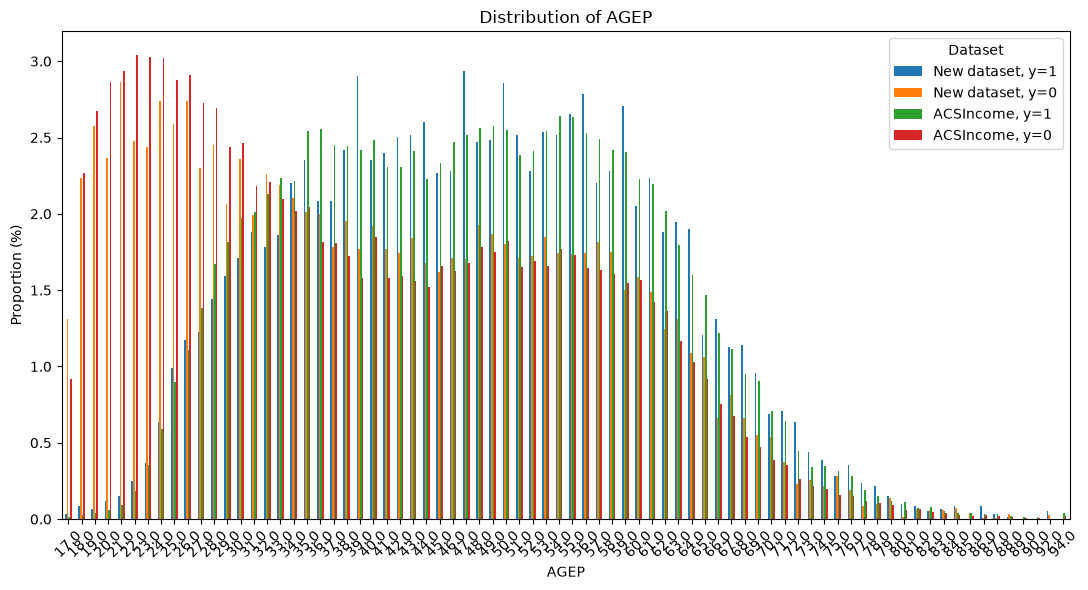

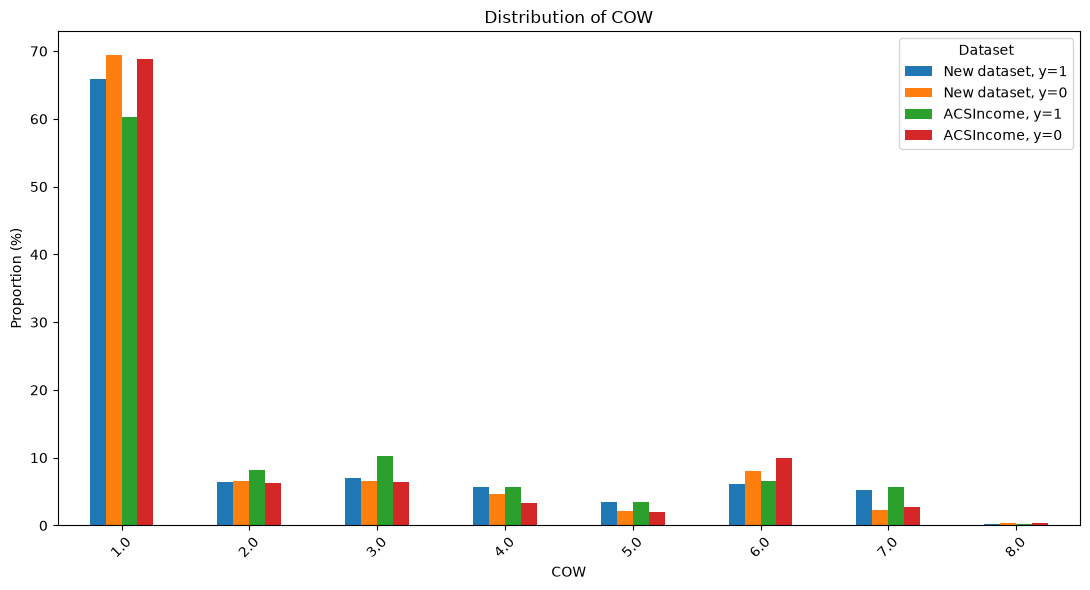

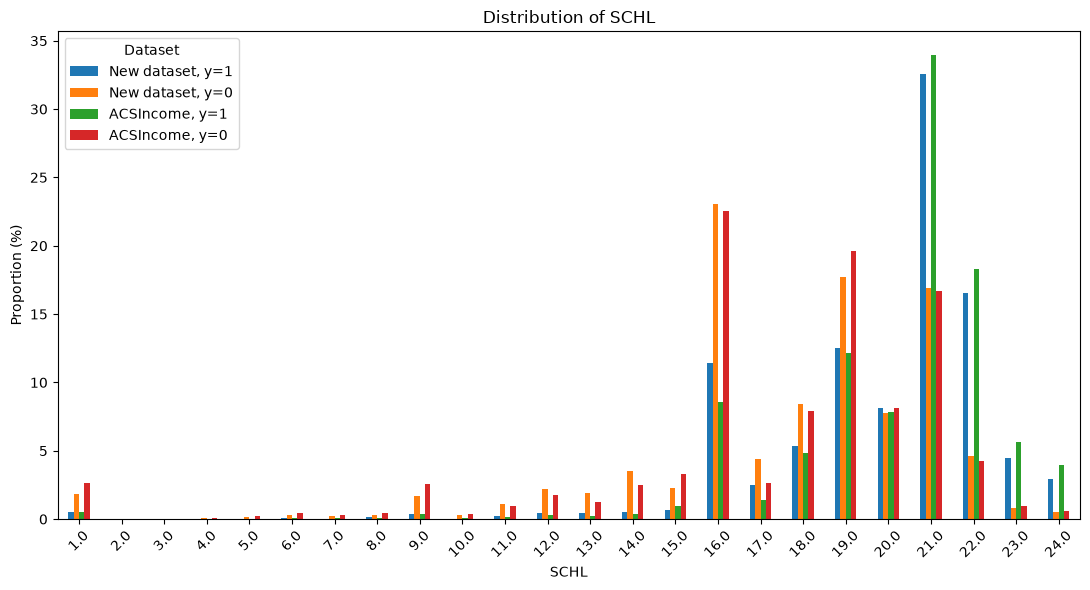

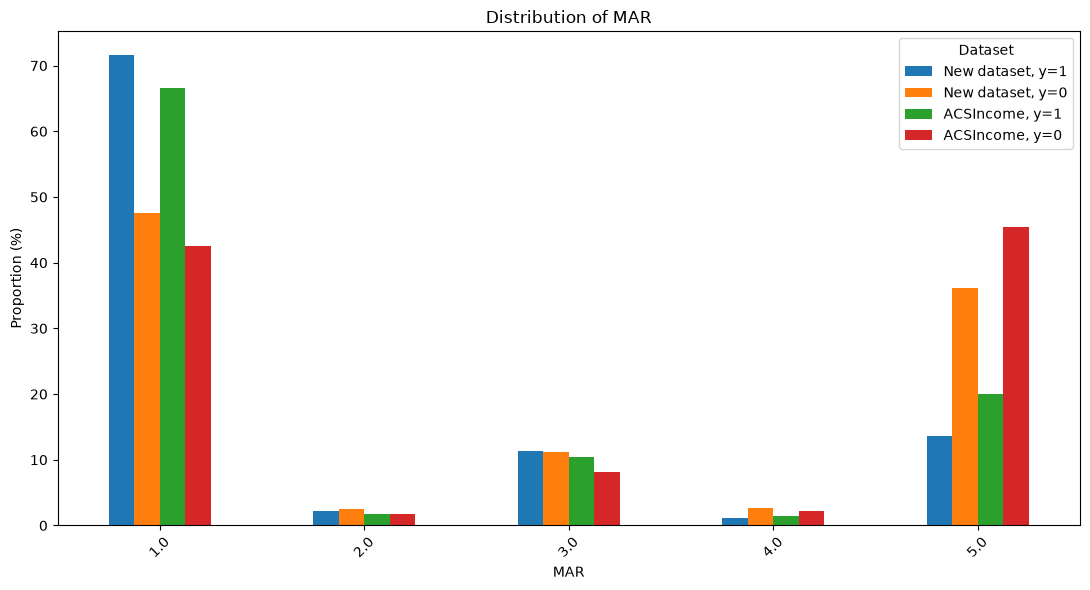

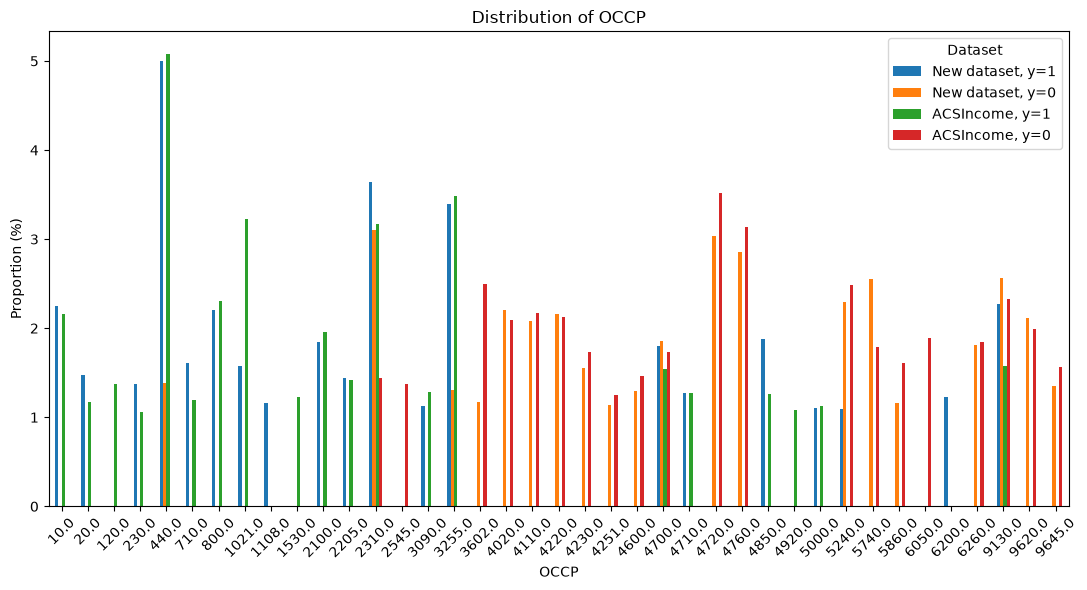

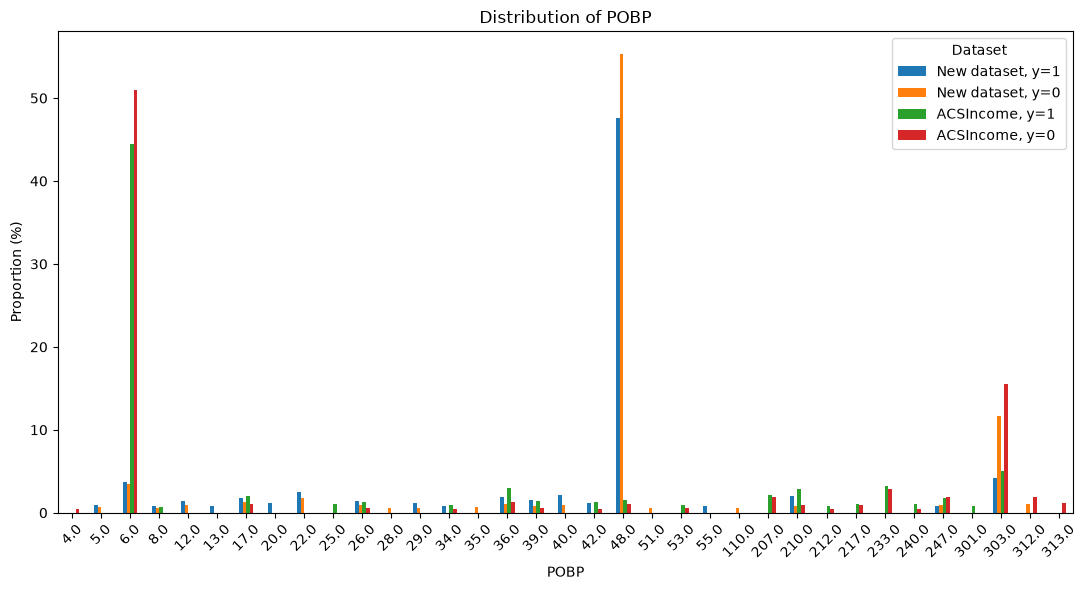

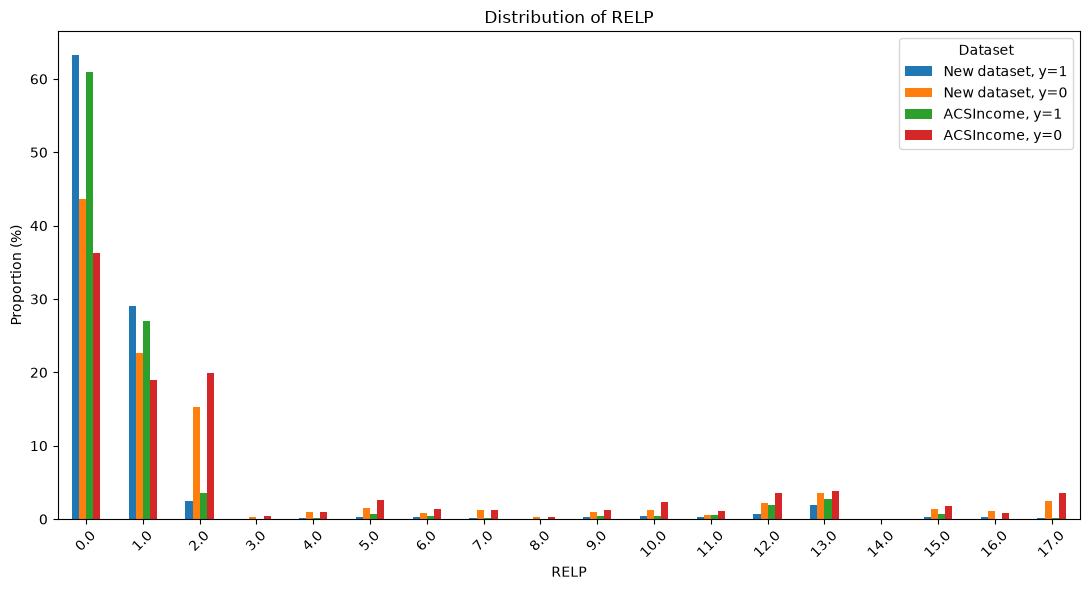

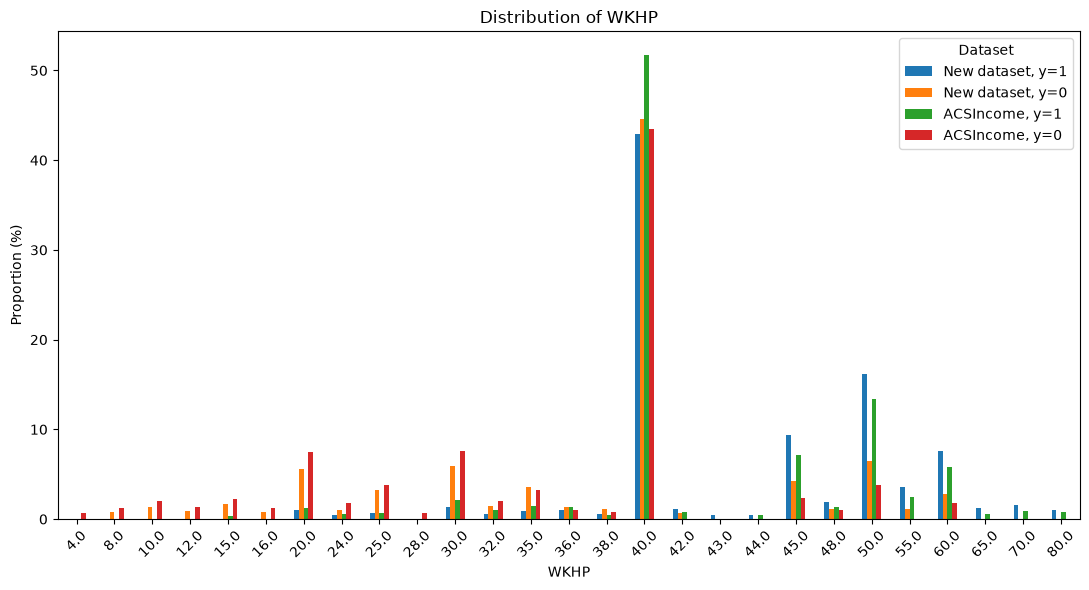

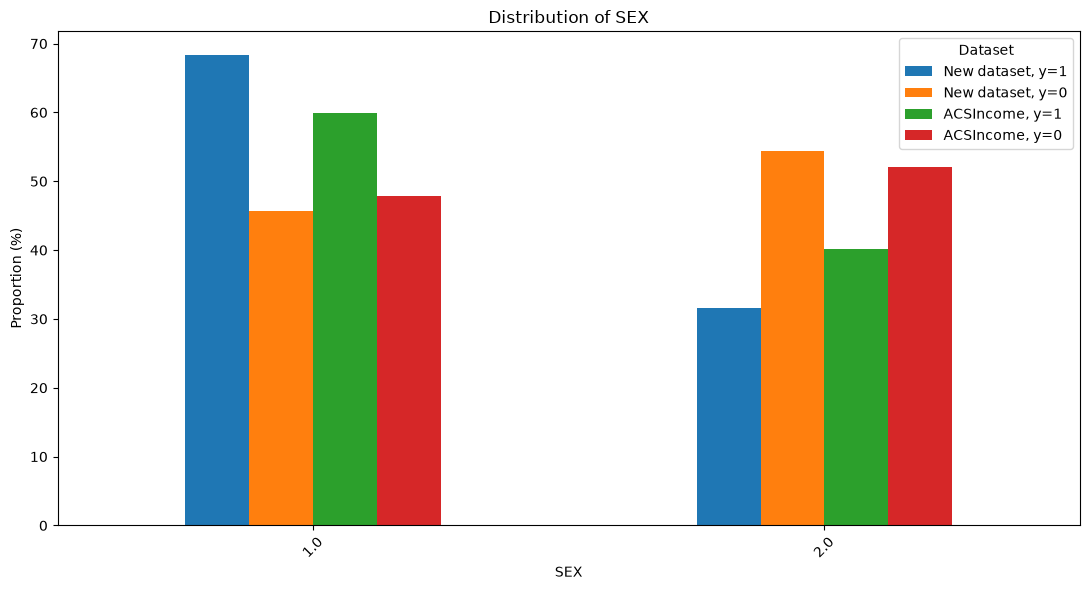

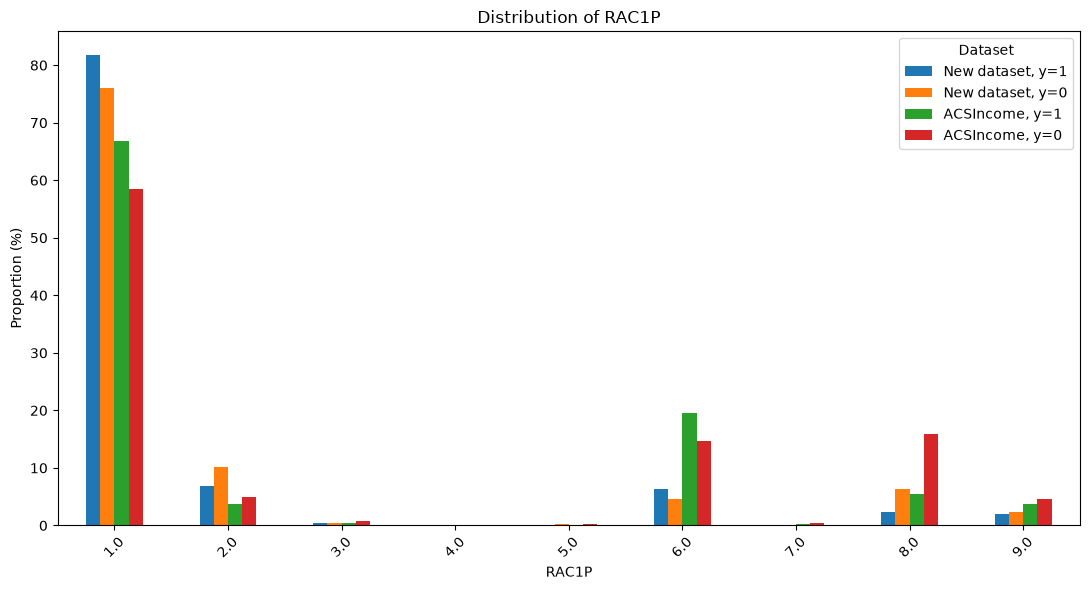

In [44]:
for col in X_acs.columns:
    compare_distribution_income(col, train)

In [ ]:
X = pd.merge(X_acs, y_acs, left_index=True, right_index=True)
X_plus = X[X["PINCP"] == True]
X_minus = X[X["PINCP"]==False]

# Calculate proportions 
prop21 = X_plus["AGE"].value_counts(normalize=True) * 100
prop20 = X_minus["AGE"].value_counts(normalize=True) * 100

# Combine into one DataFrame so categories are aligned 
proportions = pd.concat( [prop21, prop20], axis=1, keys=["New dataset, y=0", "ACSIncome, y=1", "ACSIncome, y=0"] ).fillna(0) 

# Plot 
proportions = proportions.sort_values(column)
proportions.plot( kind="bar", figsize=(11, 6) ) 
plt.xlabel(column) 
plt.ylabel("Proportion (%)") 
plt.title(f"Distribution of {column}") 
plt.xticks(rotation=45) 
plt.legend(title="Dataset") 
plt.tight_layout() 
plt.show()

Most of the above seem resonable, but it is worrying that difference between man vs woman for a high income has grown in the new dataset.

## Creating hypotheses

I will make the following hypotheses:

1) Most people in (both) datasets are white, but the proportion of white people have increased in the new dataset. I will investigate if the race-bias will be more pronouced for the new dataset than ASCIncome

2) The new dataset sees an increased difference between high earning men and women. I will investigate if model will overestimate men's income and underestimate women's income

## Define and train models

Last week, I decided not to include features, because I didn't want income to depend on your sex, marital status, place of birth or race. However, the model that I am training is not for deciding e.g. if someone should be able to take a loan, but rather it is to predict whether they have an high or low incomst i.e. the model is not intended for decision-making. Since income is frankly sometimes depending on these attributes, I will include them in the model, and then investigate if, based on this more elaborate dataset, that model has one or more biases.

In [46]:
LABEL = "income_observed"
ID = "row_id"
SENSITIVE = ["SEX_group", "RACE_group"]

FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP", "SEX", "RAC1P"]
NUMERIC = ["AGEP", "WKHP"]

def make_model(frame, C=1.0):
    numeric = [c for c in NUMERIC if c in frame.columns]
    categorical = [c for c in FEATURE_COLUMNS if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000, C=C)),
    ])


# Logistic regression model
model = make_model(train[FEATURE_COLUMNS])
model.fit(train[FEATURE_COLUMNS], train["income_observed"])
val_score = model.predict_proba(validation[FEATURE_COLUMNS])[:, 1]
val_pred = (val_score >= .5).astype(int)

logistic_accuracy = accuracy_score(validation["income_observed"], val_pred)

# Baseline model
baseline_pred = (validation['WKHP']> 40).astype(int)
baseline_accuracy = accuracy_score(validation["income_observed"], baseline_pred)

print(f"Logistic regression accuracy: {logistic_accuracy:.3f}")
print(f"WKHP baseline accuracy:       {baseline_accuracy:.3f}")

Logistic regression accuracy: 0.798
WKHP baseline accuracy:       0.703


In [49]:
metrics = {
    "n": count,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "selection_rate": selection_rate,
    "TPR_recall": recall_score,
    "FPR": false_positive_rate_metric,
    "PPV_precision": lambda y, p: precision_score(y, p, zero_division=0),
    "NPV": negative_predictive_value_metric,
    "TNR": true_negative_rate_metric,
    "confusion_matrix": confusion_matrix_binary
}

mf = MetricFrame(metrics=metrics, y_true=validation['income_observed'], y_pred=val_pred, sensitive_features=validation['SEX_group'])
mf_race = MetricFrame(metrics=metrics, y_true=validation['income_observed'], y_pred=val_pred, sensitive_features=validation['RACE_group'])


print("Overall threshold metrics")
display(pd.Series(mf.overall))
print("By group")
display(mf.by_group)
display(mf_race.by_group)

for s in SENSITIVE:
    fairness_summary = pd.Series({
        "demographic_parity_difference": demographic_parity_difference(validation['income_observed'], val_pred, sensitive_features=validation[s]), 
        "demographic_parity_ratio": demographic_parity_ratio(validation['income_observed'], val_pred, sensitive_features=validation[s]),
        "equalized_odds_difference": equalized_odds_difference(validation['income_observed'], val_pred, sensitive_features=validation[s]),
        "equalized_odds_ratio": equalized_odds_ratio(validation['income_observed'], val_pred, sensitive_features=validation[s]),
    })
    print(s)
    display(fairness_summary)

Overall threshold metrics


n                                          6000
accuracy                                  0.798
balanced_accuracy                      0.757829
selection_rate                         0.293333
TPR_recall                              0.63659
FPR                                    0.120931
PPV_precision                          0.725568
NPV                                    0.828066
TNR                                    0.879069
confusion_matrix     [[3511, 483], [729, 1277]]
dtype: object

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix
SEX_group,,,,,,,,,,
Female,2812,0.806543,0.659754,0.147226,0.395833,0.076325,0.596618,0.842786,0.923675,"[[2021, 167], [377, 247]]"
Male,3188,0.790464,0.785162,0.422208,0.745297,0.174972,0.765230,0.808903,0.825028,"[[1490, 316], [352, 1030]]"


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix
RACE_group,,,,,,,,,,
AIAN specified/other,15,0.933333,0.750000,0.066667,0.500000,0.000000,1.000000,0.928571,1.000000,"[[13, 0], [1, 1]]"
American Indian,20,0.900000,0.843750,0.200000,0.750000,0.062500,0.750000,0.937500,0.937500,"[[15, 1], [1, 3]]"
Asian,318,0.795597,0.790088,0.402516,0.769231,0.189055,0.703125,0.857895,0.810945,"[[163, 38], [27, 90]]"
Black,526,0.790875,0.631740,0.129278,0.330645,0.067164,0.602941,0.818777,0.932836,"[[375, 27], [83, 41]]"
Other race,281,0.871886,0.679368,0.099644,0.404762,0.046025,0.607143,0.901186,0.953975,"[[228, 11], [25, 17]]"
Pacific Islander,3,1.000000,1.000000,0.333333,1.000000,0.000000,1.000000,1.000000,1.000000,"[[2, 0], [0, 1]]"
Two or more races,134,0.791045,0.701484,0.201493,0.487179,0.084211,0.703704,0.813084,0.915789,"[[87, 8], [20, 19]]"
White,4703,0.793749,0.763694,0.319583,0.658915,0.131527,0.735196,0.821250,0.868473,"[[2628, 398], [572, 1105]]"


SEX_group


demographic_parity_difference    0.274982
demographic_parity_ratio         0.348705
equalized_odds_difference        0.349463
equalized_odds_ratio             0.436214
dtype: float64

RACE_group


demographic_parity_difference    0.335849
demographic_parity_ratio         0.165625
equalized_odds_difference        0.669355
equalized_odds_ratio             0.000000
dtype: float64

All reported numbers are (female, male)
True positive rate is much lower for females than for males, which indicate that the model more often predict women to have a low income despite them having a high income (0.40 vs 0.75)
False positive rate is higher for men than women (0.17,0.08), which means that the model is more likely to label a man as having a high income despite it not being true than women.
The selection rate is higher for men (0.15 vs 0.42) meaning that 42% of men are predicted to have a high income, while only 15% of women.
Male precision score is higher (0.60,0.77) meaning that the ratio of correct positive guesses is higher for men (precision=TP/(TP+FP))
True negative rate (TN/(TN+FP)) is higher for women (0.92,0.83) meaning that the model is more likely to correctly predict women with low income than men with low income
Difference between selection rate is 0.27.
Equalized odds difference is 0.35, which is max(diff(TPR),diff(FPR)). This seems quite high


For race:
Accuracy varies a bit over the races (between 0.79 and 1.0)
Selection rate is highest for Asians (0.40), then Pacific Islanders (0.33) and then Whites (0.32). For African American, it is only 0.13.
TPR for African Americans is half of that of whites (0.33, 0.66)
FPR is highest for Asians (0.18) and then whites (0.13). For African Americans, it is only 0.07
Precision score is higher for whites than African americans
Difference between selection rate is 0.34
Equalized odds difference is 0.67, but we also have some groups which are really small, so it is difficult to tell

Comparison to ASCIncome:
For whites, selection rate, TPR, FPR, NPV and TNR have all gone down
For African americans, selection rate and TPR has plummeted. Precision and TNR has also gone down
(Before, After)
		White		Black		Asian		Diff (W/B)
Selection rate	(0.45,0.32)    (0.34,0.13)     (0.50, 0.40)	(0.11,0.19)
TPR		(0.80,0.66)    (0.66,0.33)     (0.83,0.77)	(0.14,0.33)
FPR		(0.17,0.13)    (0.16,0.07)     (0.20,0.19)	(0.01,0.06)
Precision	(0.78,0.74)    (0.69,0.60)     (0.80,0.70)	(0.09,0.14)
One could argue that the bias has not grown for the new model, though there still is a bias towards race. One thing that jumps out is how much worse the difference in TPR has gotten. The model based on the new dataset is much worse at identifying the positive cases for African Americans. But we do need to remember that this is just 2 models.  

## Explore calibration by group

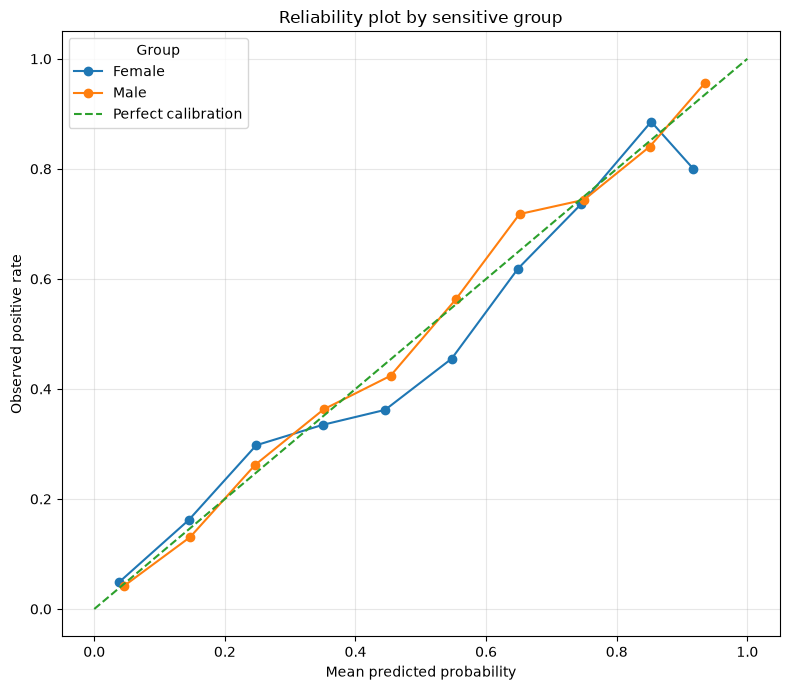

In [50]:
# Calibration by group (code from ChatGPT)

calibration_data = pd.DataFrame({
    "y_true": validation["income_observed"].to_numpy(),
    "y_prob": val_score,
    "group": validation["SEX_group"].to_numpy()
})

n_bins = 10

plt.figure(figsize=(8, 7))

for group, group_df in calibration_data.groupby("group"):
    group_df = group_df.copy()

    group_df["bin"] = pd.cut(
        group_df["y_prob"],
        bins=np.linspace(0, 1, n_bins + 1),
        include_lowest=True
    )

    calibration_group = (
        group_df
        .groupby("bin", observed=False)
        .agg(
            n=("y_true", "size"),
            mean_predicted=("y_prob", "mean"),
            observed_rate=("y_true", "mean")
        )
    )

    # Only plot bins containing observations
    calibration_group = calibration_group[calibration_group["n"] > 0]

    plt.plot(
        calibration_group["mean_predicted"],
        calibration_group["observed_rate"],
        marker="o",
        label=str(group)
    )

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Reliability plot by sensitive group")
plt.legend(title=SENSITIVE if isinstance(SENSITIVE, str) else "Group")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The plot shows that the model is quite well calibrated, but worse for women than men

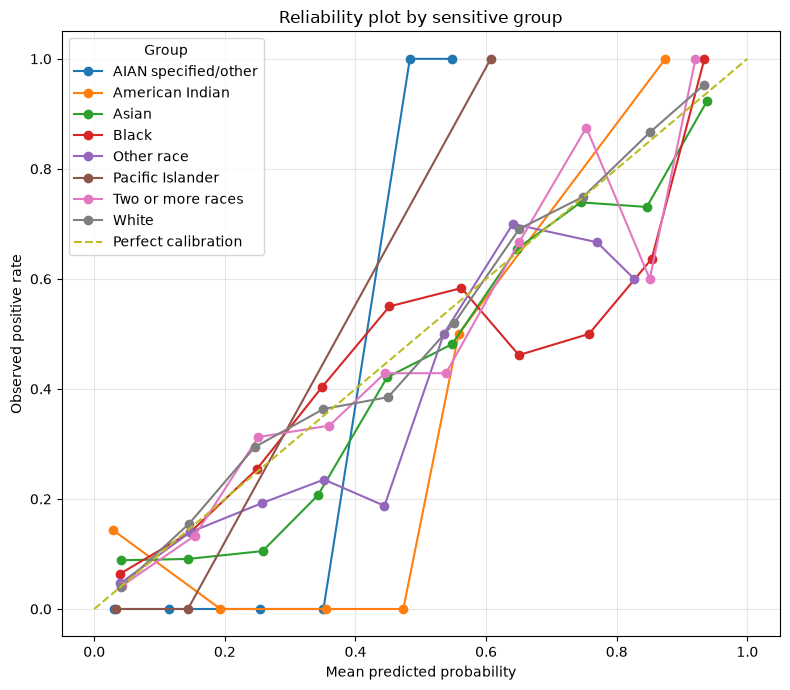

In [52]:
# Calibration by group (code from ChatGPT)

calibration_data = pd.DataFrame({
    "y_true": validation["income_observed"].to_numpy(),
    "y_prob": val_score,
    "group": validation["RACE_group"].to_numpy()
})

n_bins = 10

plt.figure(figsize=(8, 7))

for group, group_df in calibration_data.groupby("group"):
    group_df = group_df.copy()

    group_df["bin"] = pd.cut(
        group_df["y_prob"],
        bins=np.linspace(0, 1, n_bins + 1),
        include_lowest=True
    )

    calibration_group = (
        group_df
        .groupby("bin", observed=False)
        .agg(
            n=("y_true", "size"),
            mean_predicted=("y_prob", "mean"),
            observed_rate=("y_true", "mean")
        )
    )

    # Only plot bins containing observations
    calibration_group = calibration_group[calibration_group["n"] > 0]

    plt.plot(
        calibration_group["mean_predicted"],
        calibration_group["observed_rate"],
        marker="o",
        label=str(group)
    )

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Reliability plot by sensitive group")
plt.legend(title=SENSITIVE if isinstance(SENSITIVE, str) else "Group")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The above plot does not let us conclude much, but the calibration seem quite different across races. It is perhaps best calibrated for White people, but this could be due to the fact that there is most data on people of this race. The model seems poorly calibrated for Asians and Blacks

## Mitigation

For mitigation strategies, I will try 2 things. Equalized odds for SEX and Equal opportunity for race

### SEX

In [54]:
postprocessor_sex = ThresholdOptimizer(estimator=model, constraints="equalized_odds", objective="accuracy_score", predict_method="predict_proba", prefit=True)

postprocessor_sex.fit(validation[FEATURE_COLUMNS], validation["income_observed"], sensitive_features=validation["SEX_group"])

eqodd_pred = postprocessor_sex.predict(validation[FEATURE_COLUMNS], sensitive_features=validation["SEX_group"])

In [56]:
eo_mf = MetricFrame(metrics=metrics, y_true=validation['income_observed'], y_pred=eqodd_pred, sensitive_features=validation['SEX_group'])

print("After Equalized Odds post-processing")
display(pd.Series(eo_mf.overall))
print("By group")
display(eo_mf.by_group)

eo_fairness_summary = pd.Series({
    "demographic_parity_difference": demographic_parity_difference(validation['income_observed'], eqodd_pred, sensitive_features=validation["SEX_group"]), 
    "demographic_parity_ratio": demographic_parity_ratio(validation['income_observed'], eqodd_pred, sensitive_features=validation["SEX_group"]),
    "equalized_odds_difference": equalized_odds_difference(validation['income_observed'], eqodd_pred, sensitive_features=validation["SEX_group"]),
    "equalized_odds_ratio": equalized_odds_ratio(validation['income_observed'], eqodd_pred, sensitive_features=validation["SEX_group"]),
})
display(eo_fairness_summary)

After Equalized Odds post-processing


n                                          6000
accuracy                                  0.752
balanced_accuracy                      0.687671
selection_rate                         0.243667
TPR_recall                             0.493519
FPR                                    0.118177
PPV_precision                          0.677155
NPV                                    0.776113
TNR                                    0.881823
confusion_matrix     [[3522, 472], [1016, 990]]
dtype: object

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix
SEX_group,,,,,,,,,,
Female,2812,0.796586,0.685430,0.197013,0.485577,0.114717,0.546931,0.857839,0.885283,"[[1937, 251], [321, 303]]"
Male,3188,0.712673,0.687368,0.284818,0.497106,0.122370,0.756608,0.695175,0.877630,"[[1585, 221], [695, 687]]"


demographic_parity_difference    0.087805
demographic_parity_ratio         0.691715
equalized_odds_difference        0.011529
equalized_odds_ratio             0.937458
dtype: float64

Accuracy dropped a lot for men: from 0.79 to 0.71. Selection rate dropped from 0.42 to 0.28 for men. True positive rate dropped from 0.75 to 0.50 for men. FPR increased. However, precision stayed the same for men but increased for women. NPV dropped for men from 0.8 to 0.7
Equalized odss difference dropped from 0.35 to 0.01.
The model has gotten worse at detecting when men actually have a high income, but better for women.

### RACE

In [57]:
postprocessor_race = ThresholdOptimizer(estimator=model, constraints="true_positive_rate_parity", objective="accuracy_score", predict_method="predict_proba", prefit=True)

postprocessor_race.fit(validation[FEATURE_COLUMNS], validation["income_observed"], sensitive_features=validation["RACE_group"])

eqopp_pred = postprocessor_race.predict(validation[FEATURE_COLUMNS], sensitive_features=validation["RACE_group"])

In [58]:
eop_mf = MetricFrame(metrics=metrics, y_true=validation['income_observed'], y_pred=eqopp_pred, sensitive_features=validation['RACE_group'])

print("After Equal opportunity post-processing")
display(pd.Series(eop_mf.overall))
print("By group")
display(eop_mf.by_group)

eop_fairness_summary = pd.Series({
    "demographic_parity_difference": demographic_parity_difference(validation['income_observed'], eqopp_pred, sensitive_features=validation["RACE_group"]), 
    "demographic_parity_ratio": demographic_parity_ratio(validation['income_observed'], eqopp_pred, sensitive_features=validation["RACE_group"]),
    "equalized_odds_difference": equalized_odds_difference(validation['income_observed'], eqopp_pred, sensitive_features=validation["RACE_group"]),
    "equalized_odds_ratio": equalized_odds_ratio(validation['income_observed'], eqopp_pred, sensitive_features=validation["RACE_group"]),
})
display(eop_fairness_summary)

After Equal opportunity post-processing


n                                          6000
accuracy                               0.796667
balanced_accuracy                      0.749136
selection_rate                            0.274
TPR_recall                             0.605683
FPR                                    0.107411
PPV_precision                          0.739051
NPV                                    0.818411
TNR                                    0.892589
confusion_matrix     [[3565, 429], [791, 1215]]
dtype: object

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix
RACE_group,,,,,,,,,,
AIAN specified/other,15,1.000000,1.000000,0.133333,1.000000,0.000000,1.000000,1.000000,1.000000,"[[13, 0], [0, 2]]"
American Indian,20,0.900000,0.750000,0.100000,0.500000,0.000000,1.000000,0.888889,1.000000,"[[16, 0], [2, 2]]"
Asian,318,0.801887,0.761130,0.276730,0.606838,0.084577,0.806818,0.800000,0.915423,"[[184, 17], [46, 71]]"
Black,526,0.796578,0.730280,0.252852,0.604839,0.144279,0.563910,0.875318,0.855721,"[[344, 58], [49, 75]]"
Other race,281,0.818505,0.736302,0.217082,0.619048,0.146444,0.426230,0.927273,0.853556,"[[204, 35], [16, 26]]"
Pacific Islander,3,0.666667,0.500000,0.000000,0.000000,0.000000,0.000000,0.666667,1.000000,"[[2, 0], [1, 0]]"
Two or more races,134,0.813433,0.747503,0.238806,0.589744,0.094737,0.718750,0.843137,0.905263,"[[86, 9], [16, 23]]"
White,4703,0.793536,0.751699,0.281948,0.605844,0.102445,0.766214,0.804264,0.897555,"[[2716, 310], [661, 1016]]"


demographic_parity_difference    0.281948
demographic_parity_ratio         0.000000
equalized_odds_difference        1.000000
equalized_odds_ratio             0.000000
dtype: float64

TPR rate became much worse for African Americans. Accuracy is the same. Selection rate increased. Precision decreased.

The results incidate that it was the wrong mitigation strategy

## Re-exploring the data

At this point, after talking to my group, I need to explore the effect of batches. I will take a short look at the data distribution and then judge whether to update my results

In [59]:
train.columns

Index(['row_id', 'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP',
       'SEX', 'RAC1P', 'SEX_group', 'RACE_group', 'SURVEY_BATCH',
       'income_observed'],
      dtype='str')

In [ ]:
# Just check something went wrong here first
sum(train.SEX_group.map({"Female": 2., "Male": 1.})==train.SEX)
sum(train.RACE_group.map({"White": 1., "Black": 2., "Asian": 6., "Other race": 8., "Two or more races": 9., "American Indian": 3., "AIAN specified/other": 5., "Pacific Islander": 7., "Alaska Native": 4.})==train.RAC1P)

18000

In [73]:
train_groups = train.groupby("SURVEY_BATCH")
print(train_groups.size())

SURVEY_BATCH
B01    1944
B02    1974
B03    1925
B04    2011
B05    2074
B06    2700
B07    2681
B08    2691
dtype: int64


In [104]:
def analyze_by_batch(df, batch_col="SURVEY_BATCH", top_n=20):

    categorical = [
        "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP",
        "SEX", "RAC1P", "SEX_group", "RACE_group",
        "income_observed"
    ]

    numeric = ["AGEP", "WKHP"]

    # -----------------------------
    # 1. Numeric variables
    # -----------------------------
    for col in numeric:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Distribution by batch
        sns.boxplot(
            data=df,
            x=batch_col,
            y=col,
            ax=axes[0]
        )
        axes[0].set_title(f"{col} by {batch_col}")

        # Mean by batch
        df.groupby(batch_col)[col].mean().plot(
            kind="bar",
            ax=axes[1]
        )
        axes[1].set_title(f"Mean {col} by {batch_col}")
        axes[1].set_ylabel("Mean")

        plt.tight_layout()
        plt.show()

    # -----------------------------
    # 2. Categorical variables
    # -----------------------------
    for col in categorical:

        # Top categories overall
        top = df[col].value_counts().head(top_n).index
        temp = df[df[col].isin(top)]

        # Proportion within each batch
        proportions = pd.crosstab(
            temp[batch_col],
            temp[col],
            normalize="index"
        ) * 100

        # Plot
        ax = proportions.plot(
            kind="bar",
            stacked=True,
            figsize=(12, 6)
        )

        ax.set_title(f"{col}: distribution by {batch_col}")
        ax.set_xlabel(batch_col)
        ax.set_ylabel("Percentage")
        ax.legend(
            title=col,
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

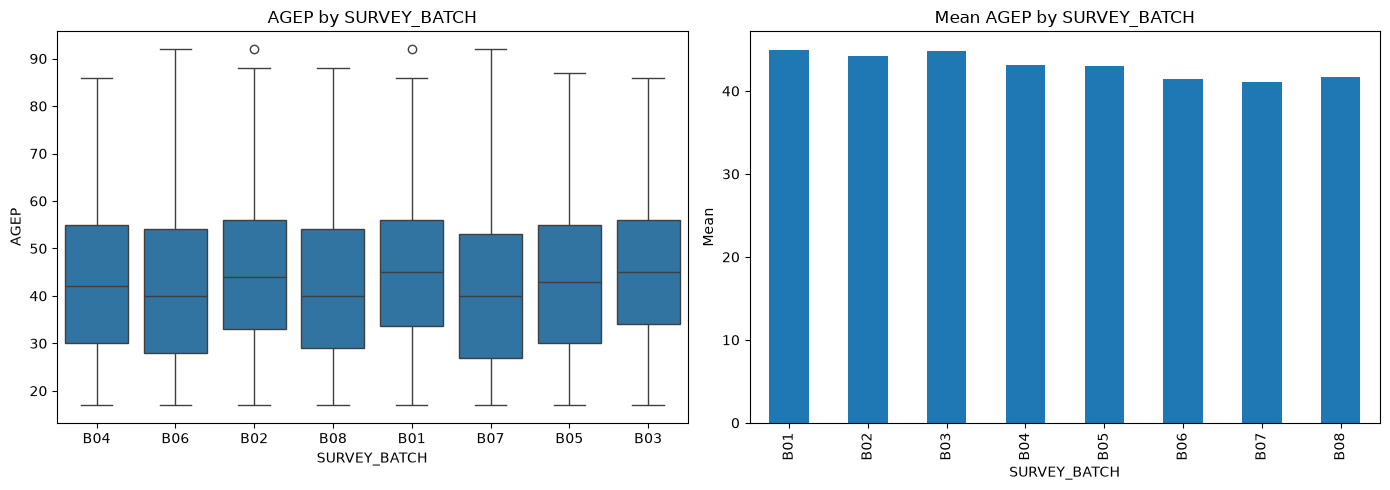

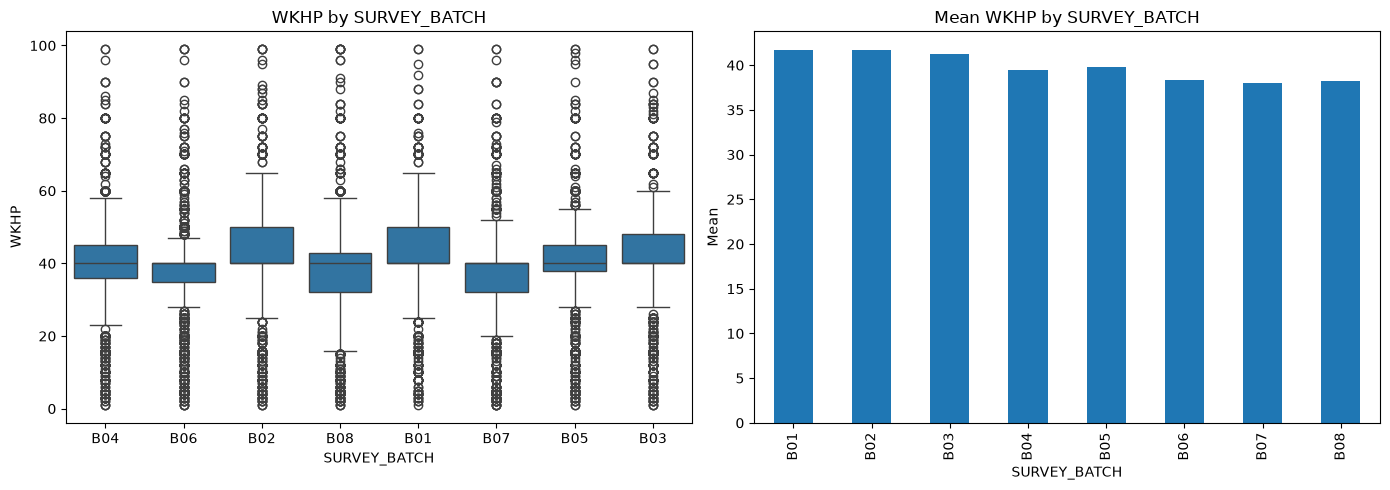

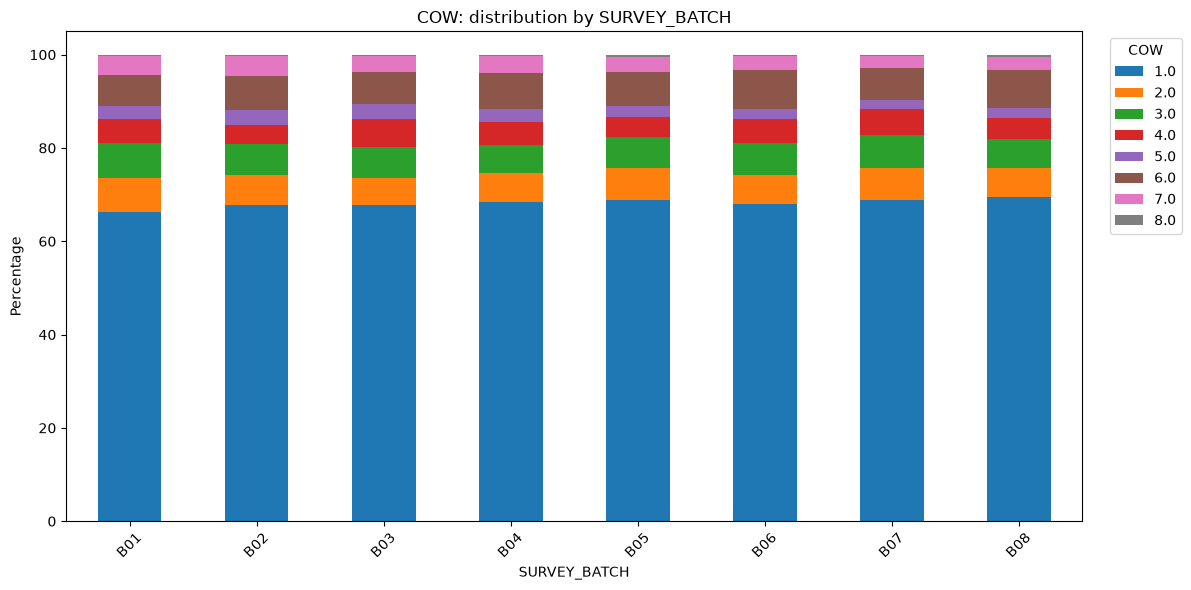

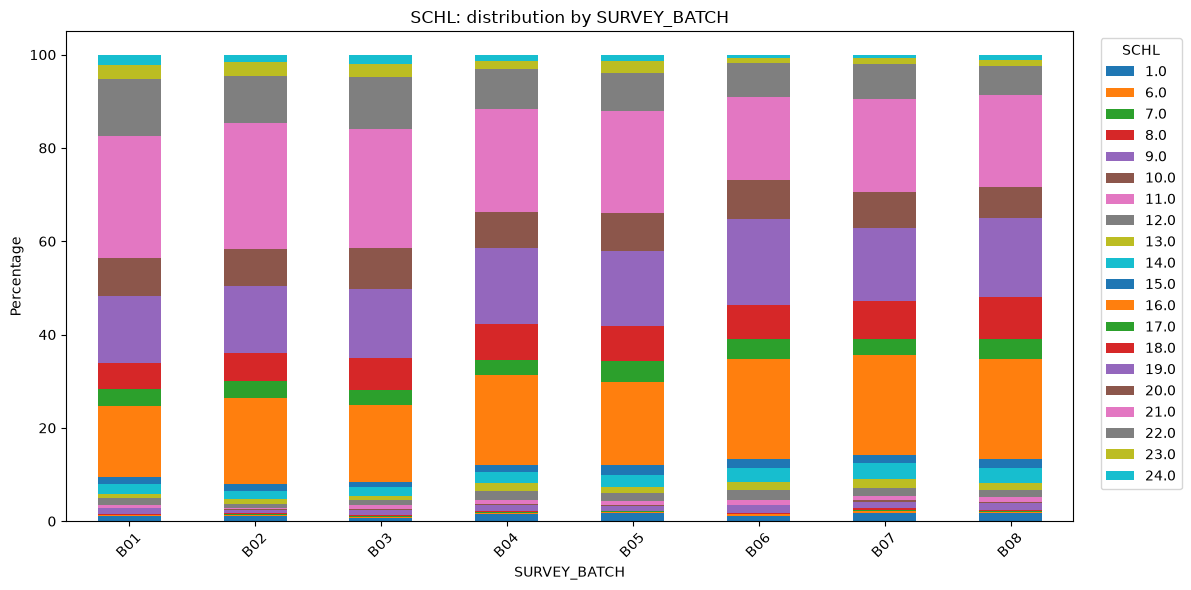

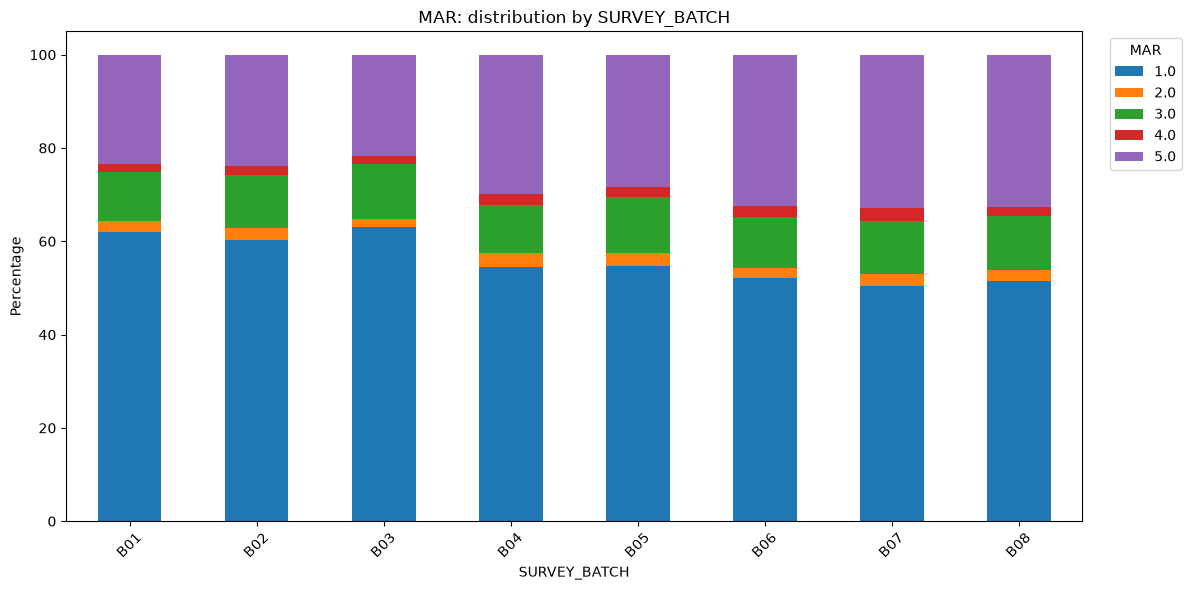

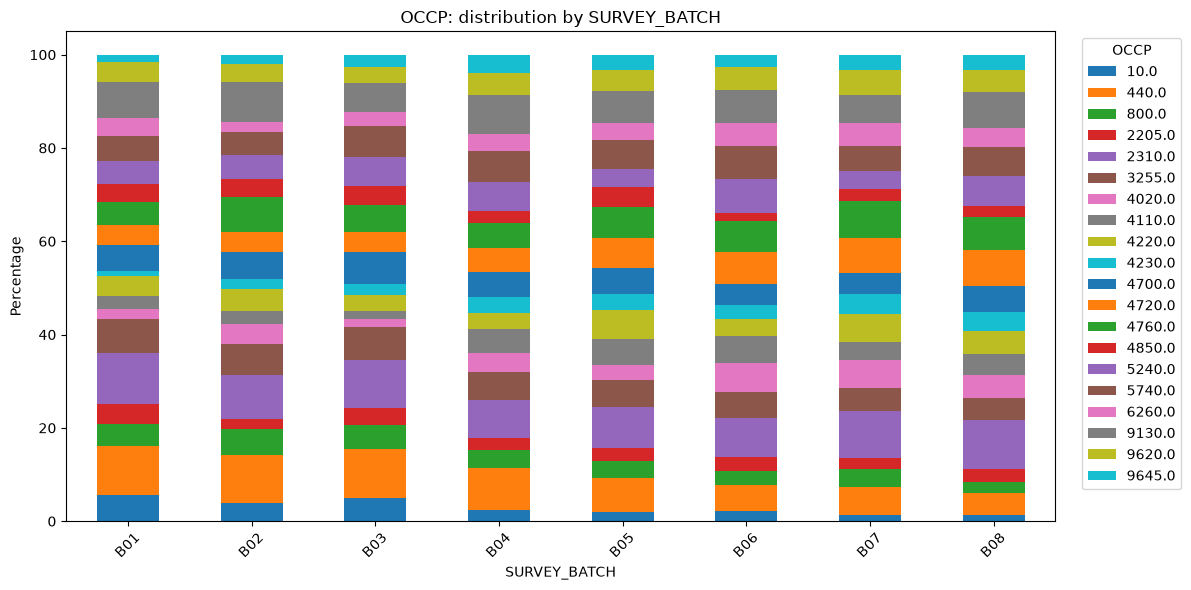

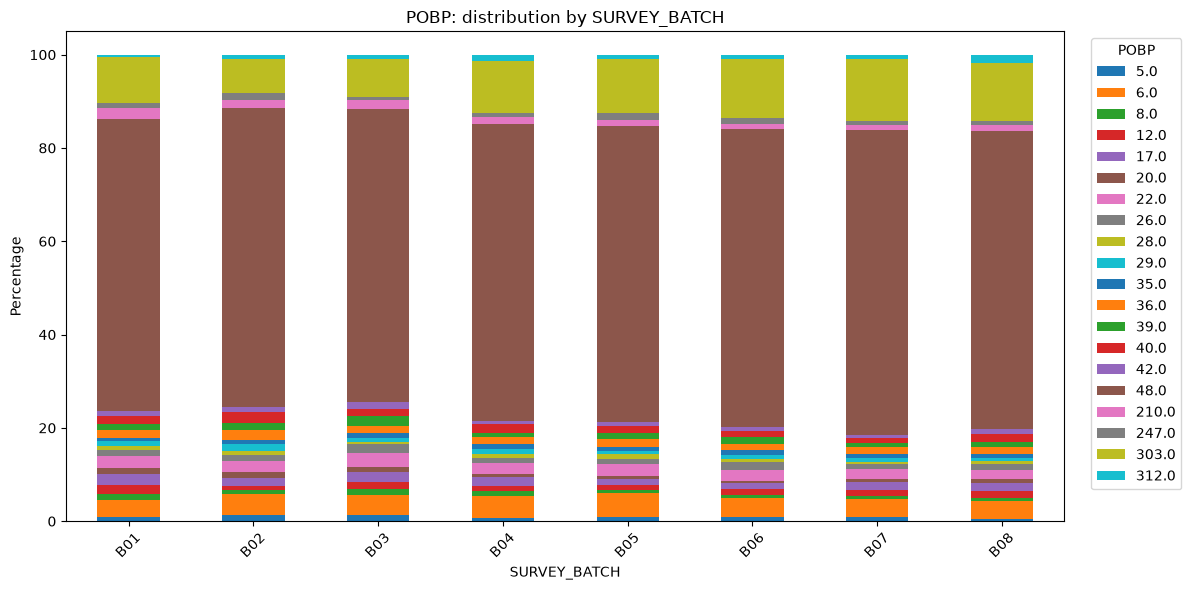

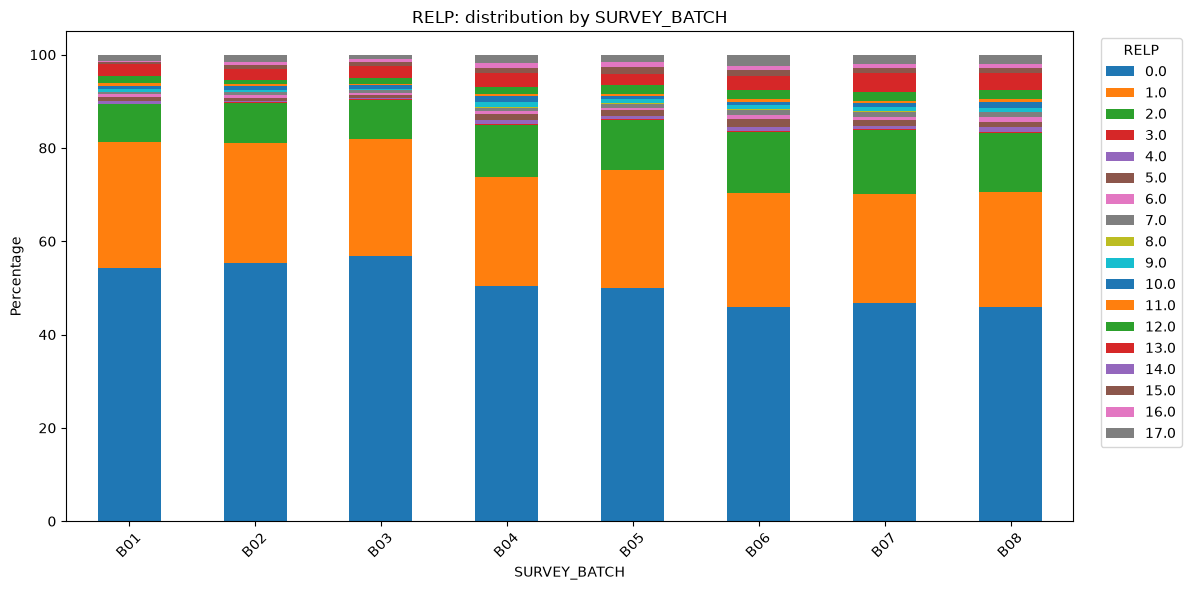

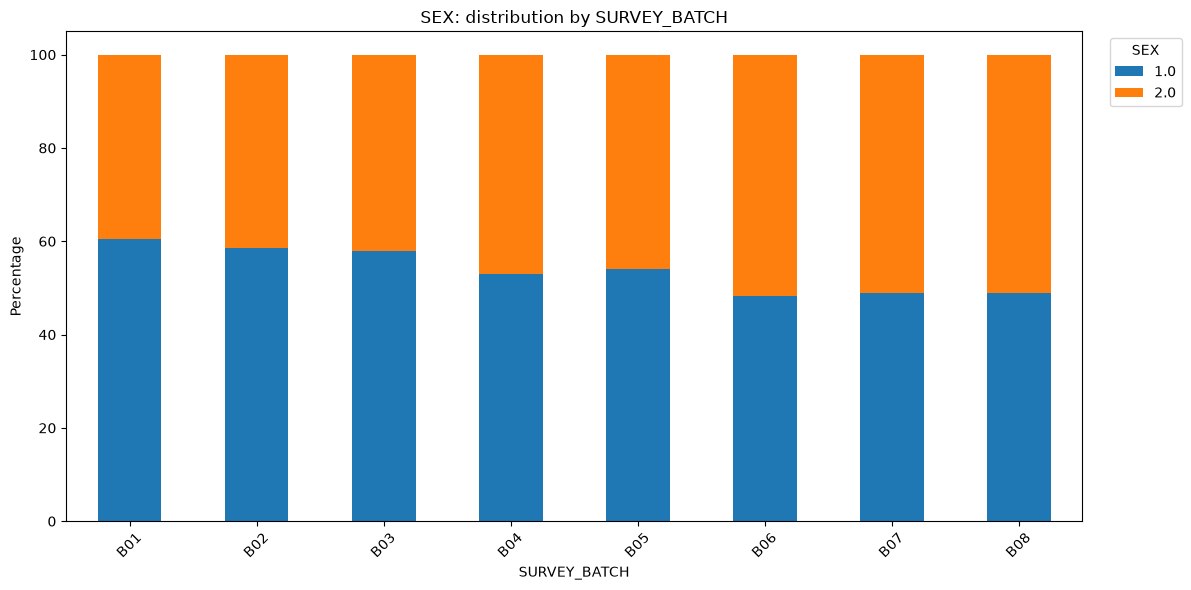

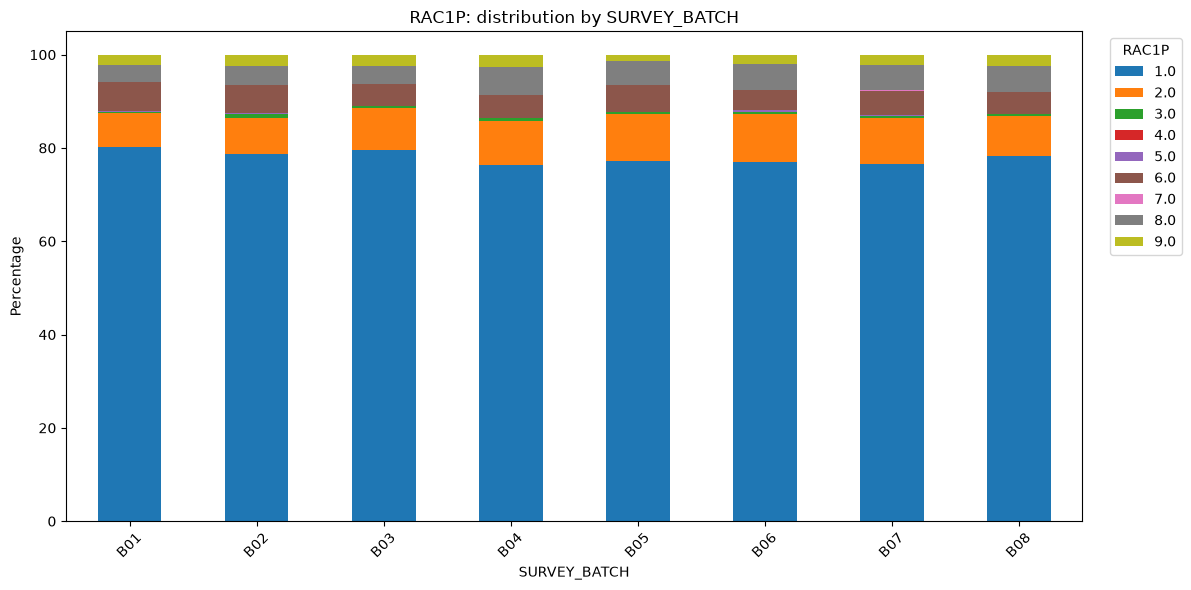

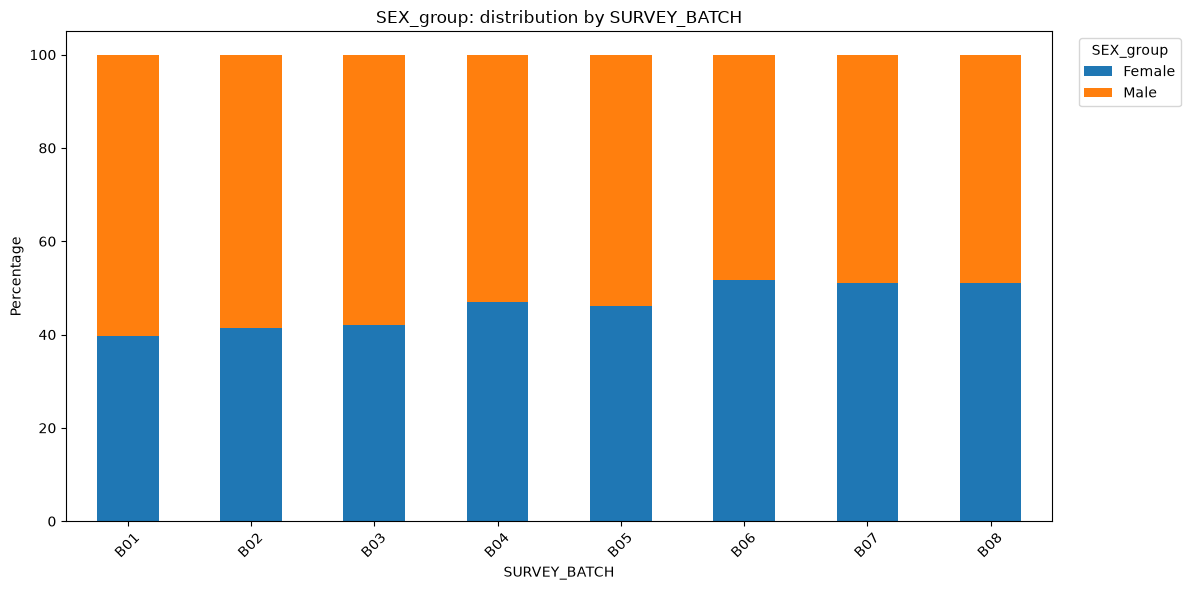

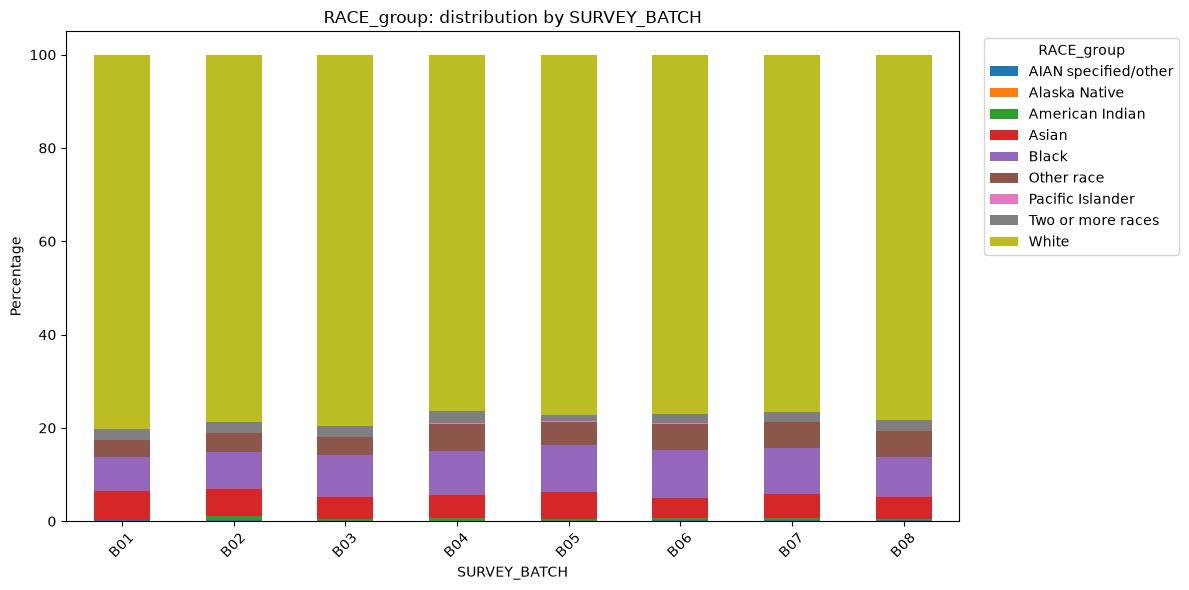

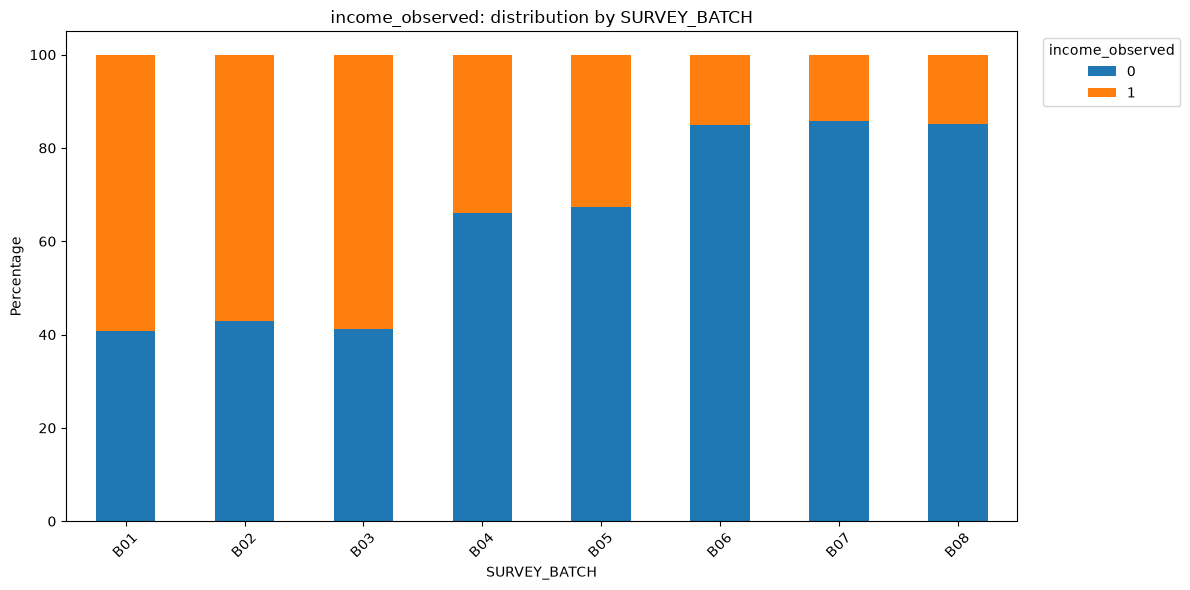

In [107]:
analyze_by_batch(train)

In [109]:
def analyze_by_batch_and_income(df, batch_col="SURVEY_BATCH", income_col="income_observed",top_n=20):

    categorical = [
        "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP",
        "SEX", "RAC1P", "SEX_group", "RACE_group"
    ]

    numeric = ["AGEP", "WKHP"]

    # =========================================================
    # CATEGORICAL VARIABLES
    # =========================================================
    for col in categorical:

        # Top categories overall
        top = df[col].value_counts().head(top_n).index
        temp = df[df[col].isin(top)].copy()

        # Distribution within batch AND income
        proportions = pd.crosstab(
            [temp[batch_col], temp[income_col]],
            temp[col],
            normalize="index"
        ) * 100

        # Plot
        ax = proportions.plot(
            kind="bar",
            stacked=True,
            figsize=(14, 7)
        )

        ax.set_title(
            f"{col}: distribution by {batch_col} and {income_col}"
        )
        ax.set_xlabel(f"{batch_col} / {income_col}")
        ax.set_ylabel("Percentage")

        plt.xticks(rotation=45, ha="right")
        plt.legend(
            title=col,
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        plt.tight_layout()
        plt.show()

    # =========================================================
    # NUMERIC VARIABLES
    # =========================================================
    for col in numeric:

        plt.figure(figsize=(12, 6))

        sns.boxplot(
            data=df,
            x=batch_col,
            y=col,
            hue=income_col
        )

        plt.title(
            f"{col}: distribution by {batch_col} and {income_col}"
        )
        plt.xlabel(batch_col)
        plt.ylabel(col)

        plt.tight_layout()
        plt.show()

In [112]:
train.MAR.value_counts()

MAR
1.0    9987
5.0    5174
3.0    2026
2.0     428
4.0     385
Name: count, dtype: int64

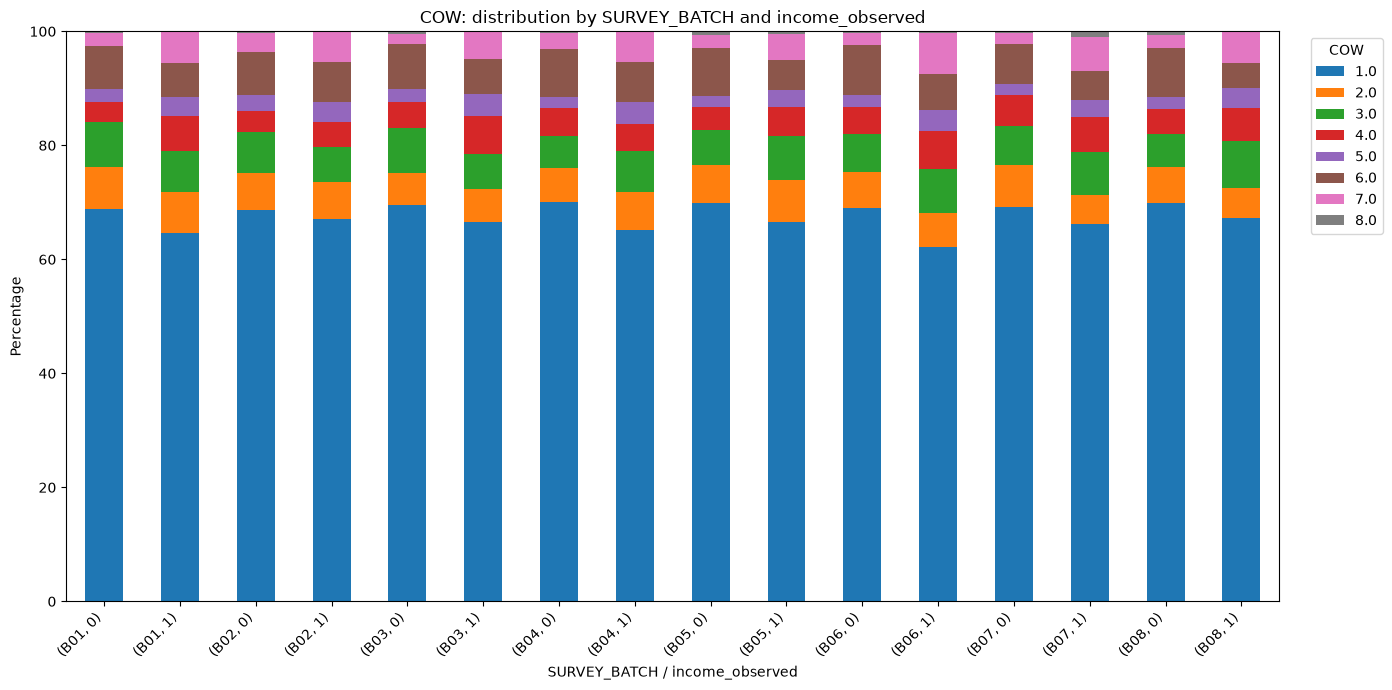

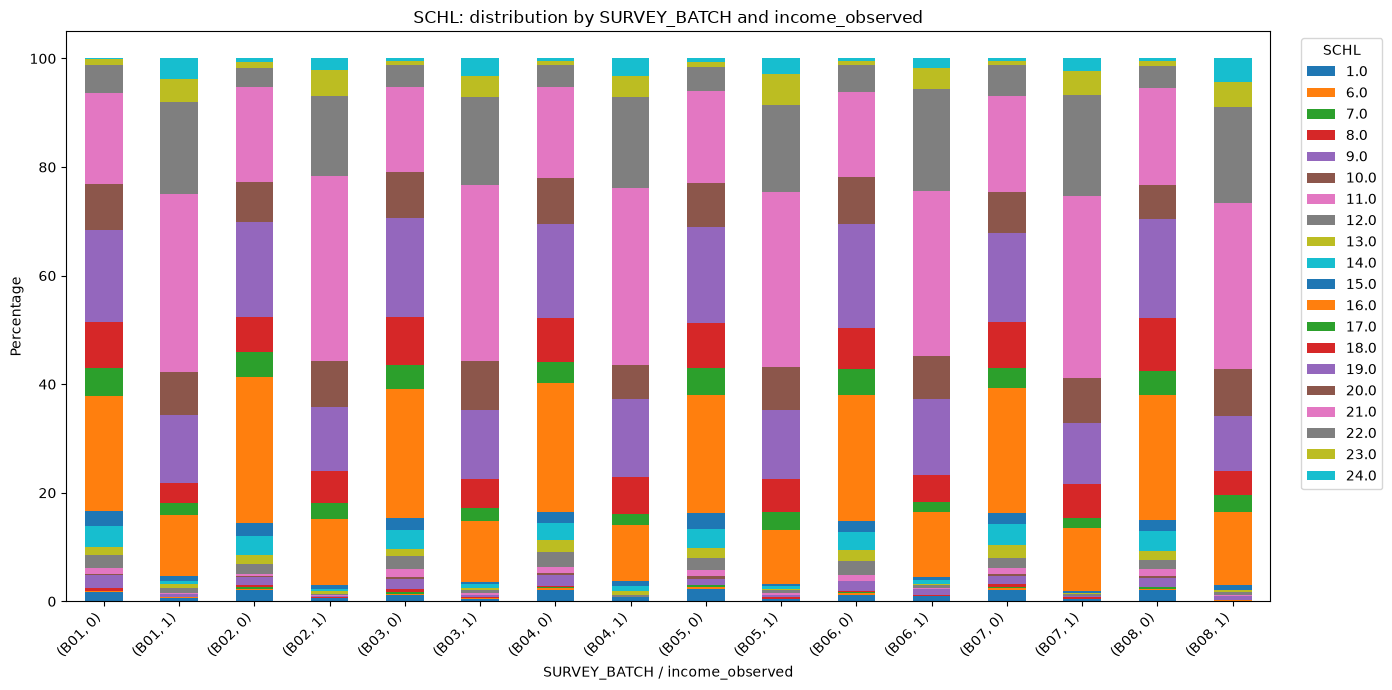

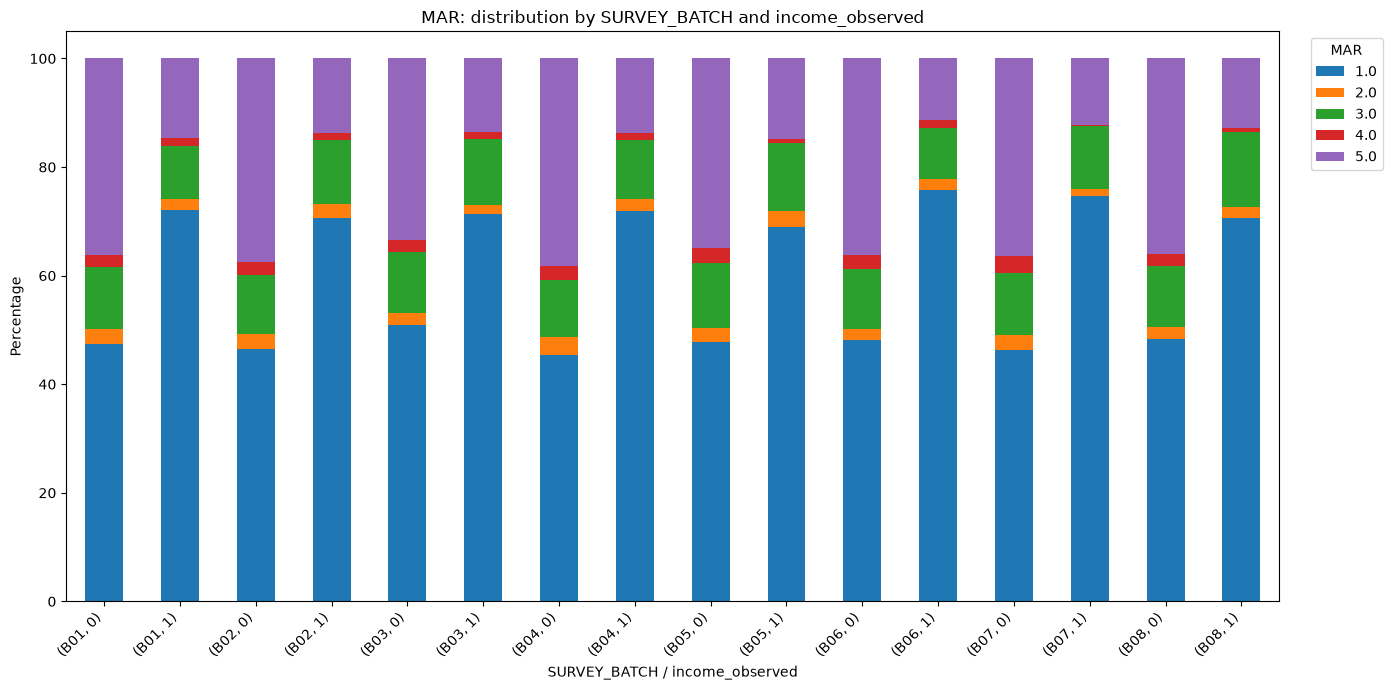

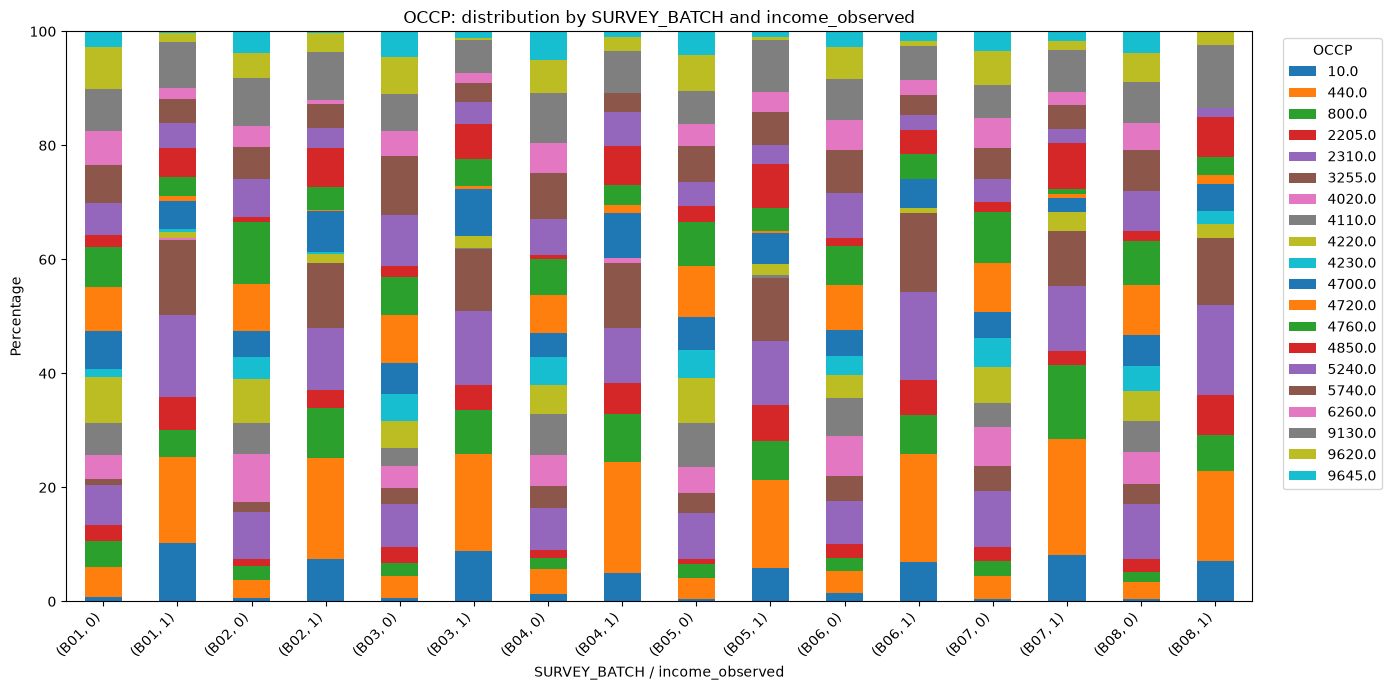

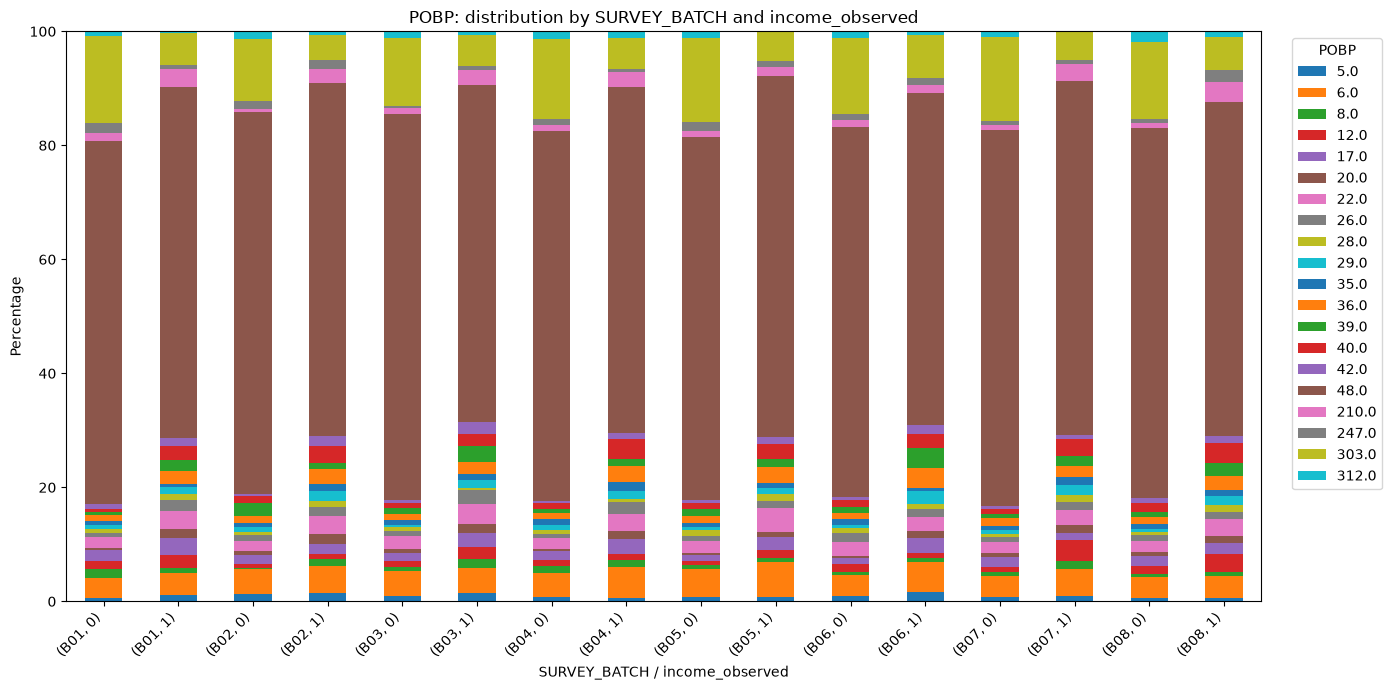

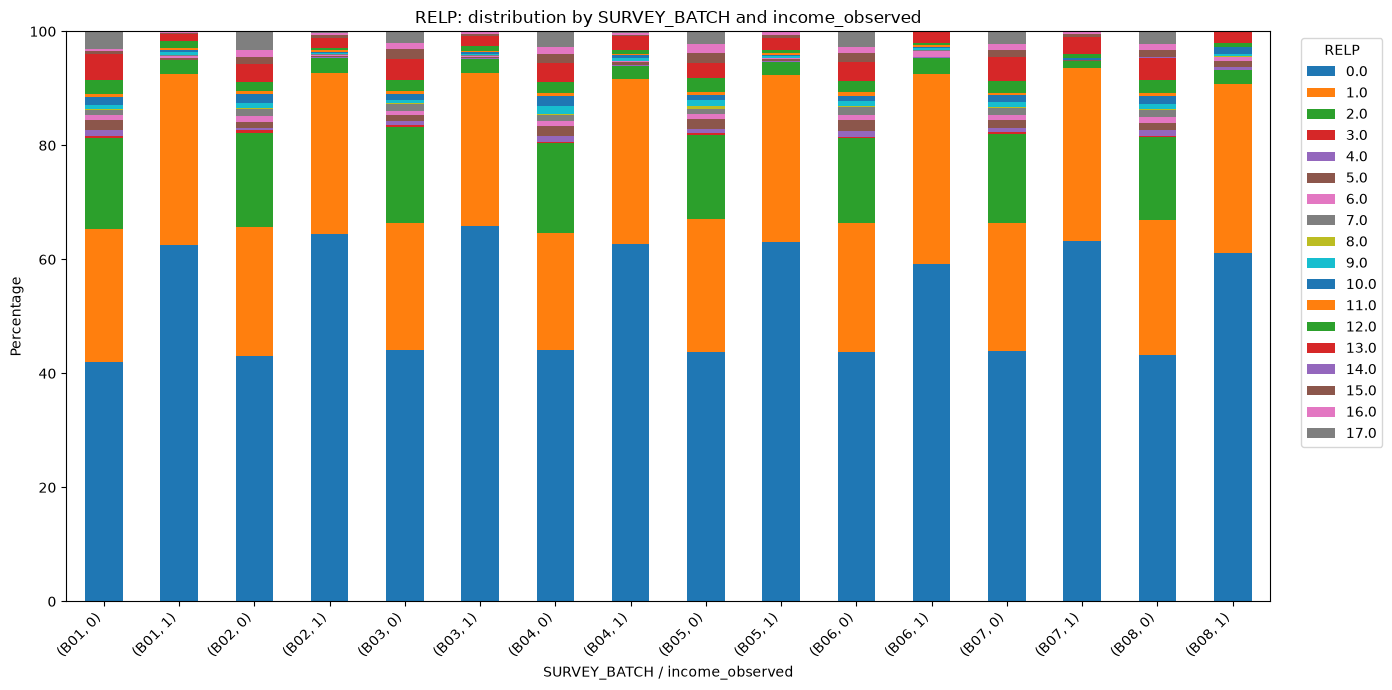

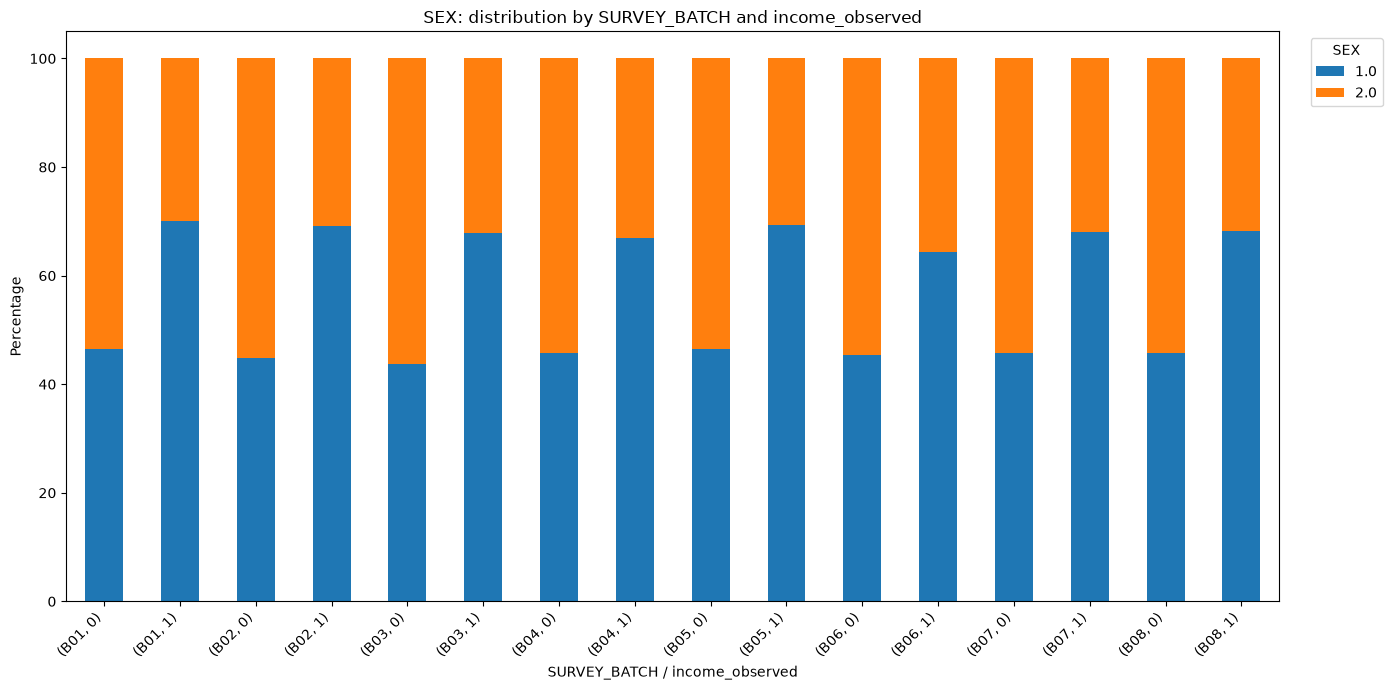

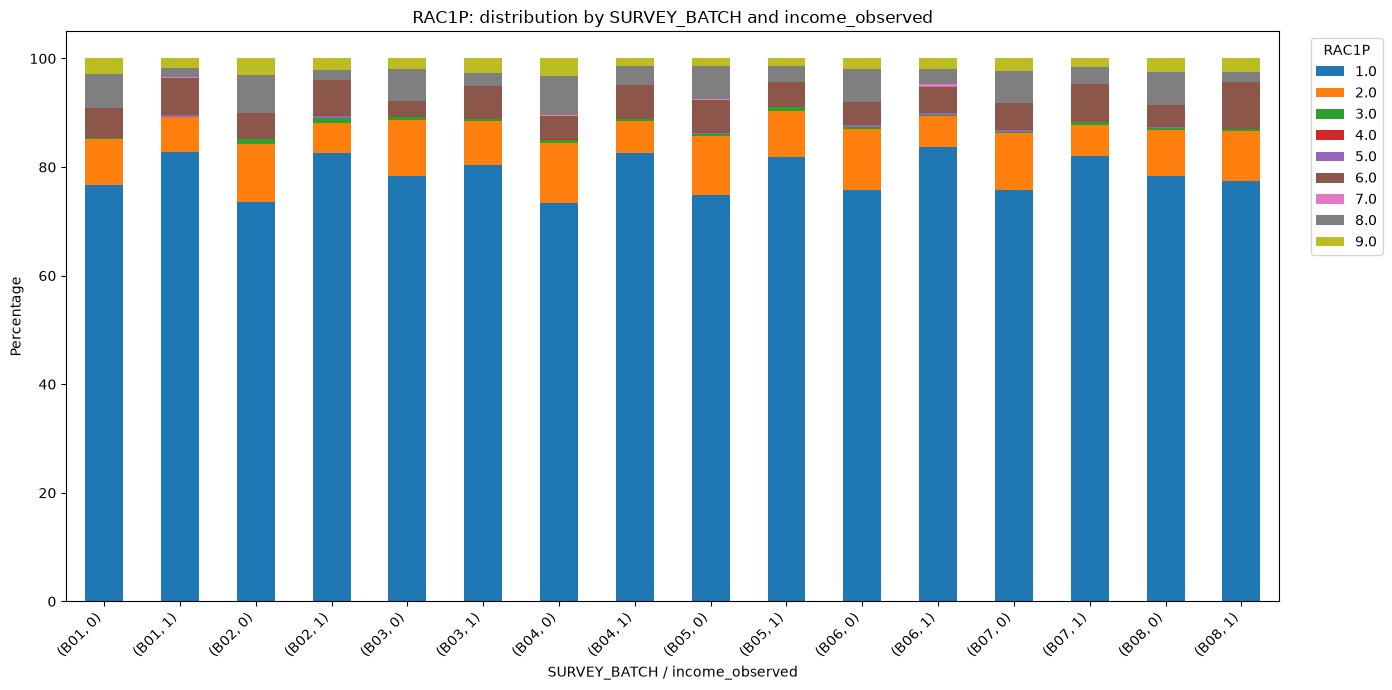

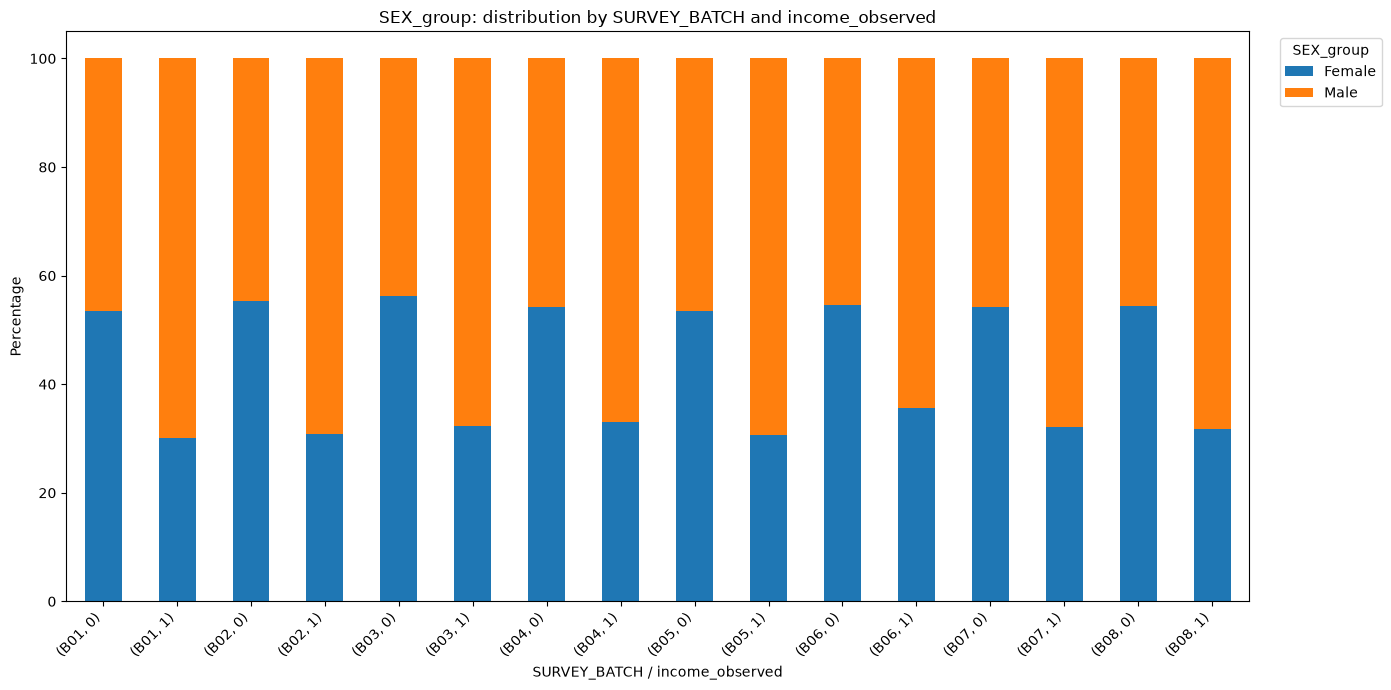

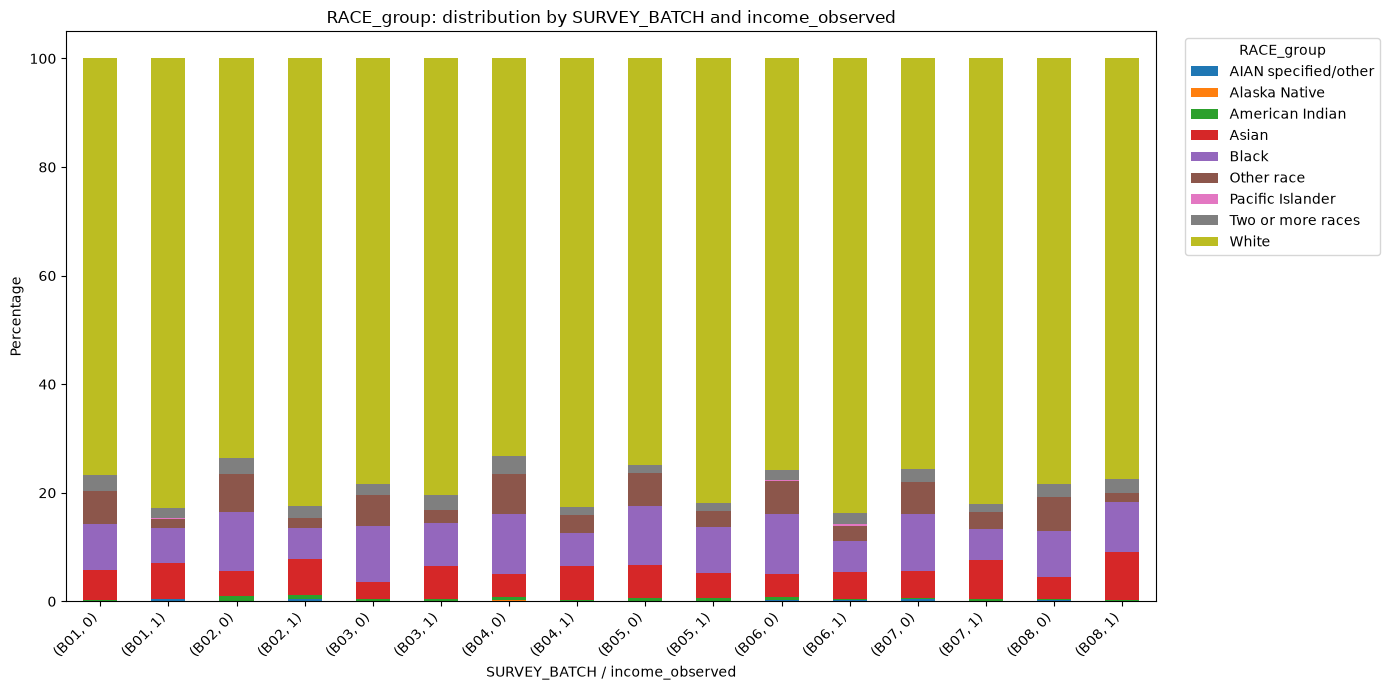

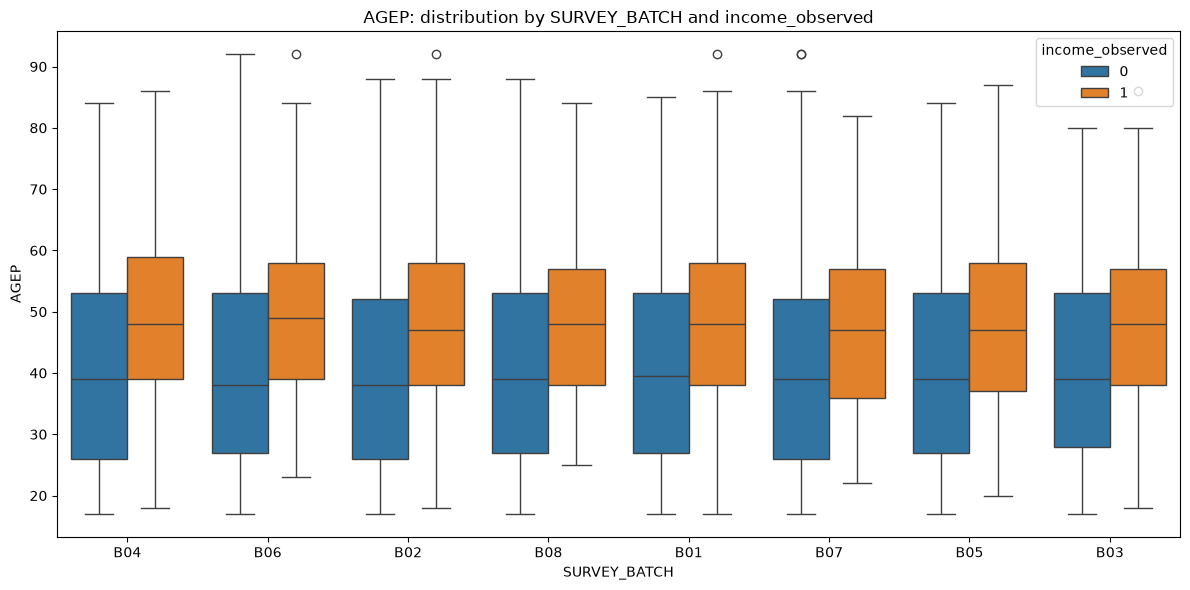

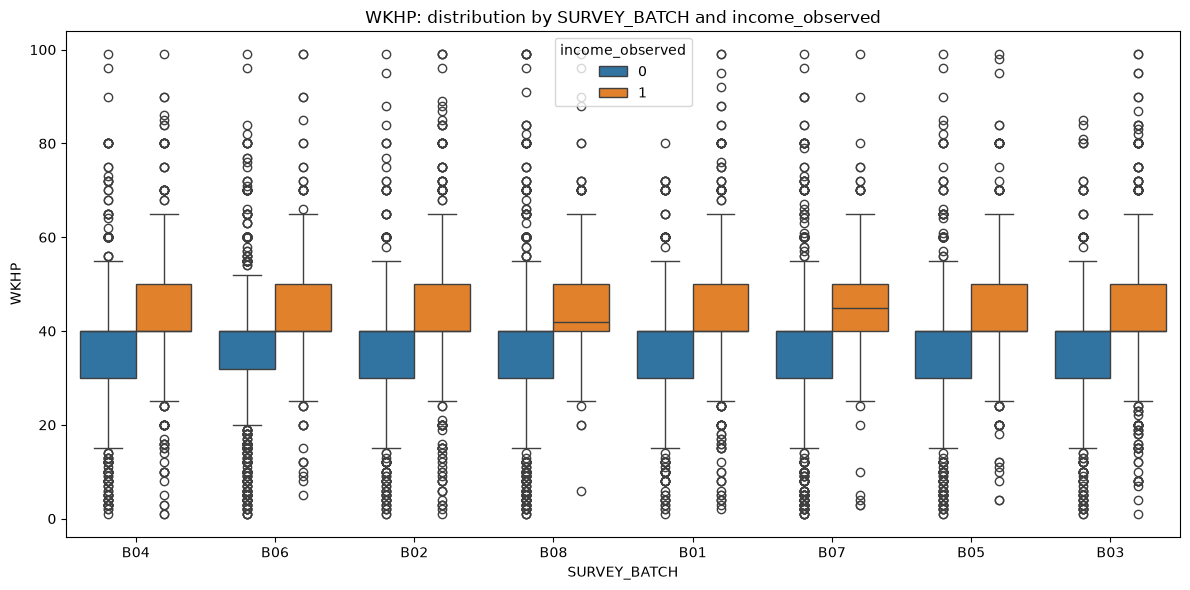

In [110]:
analyze_by_batch_and_income(train)